# 画图格式

In [8]:
import matplotlib.pyplot as plt
import os
import matplotlib.font_manager as fm


import math
import os
import random
import warnings

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
except Exception as exc:
    raise RuntimeError(
        "无法导入 torch。请在支持 PyTorch 的内核中运行该单元；"
        "若在 Windows 上遇到 DLL 初始化失败，建议重启内核后从本 notebook 第一格开始顺序运行。"
    ) from exc

try:
    from numba import njit
except Exception:
    njit = None

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

try:
    from numba import njit
except Exception:
    njit = None

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)


# ===================== 全局画图参数设置 =====================

# 1. 统一保存路径
FIGURES_DIR = "figures"
if not os.path.exists(FIGURES_DIR):
    os.makedirs(FIGURES_DIR)

# 2. 统一图的尺寸和DPI
FIG_WIDTH = 8
FIG_HEIGHT = 6
FIG_SIZE = (FIG_WIDTH, FIG_HEIGHT)
DPI = 300

# 3. 统一字体和风格
# 设置字体为 Times New Roman (或者类似的衬线字体)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
# 数学公式字体
plt.rcParams['mathtext.fontset'] = 'stix' 

# 4. 统一字体大小
FONT_SIZE_TITLE = 16
FONT_SIZE_AXIS_LABEL = 20
FONT_SIZE_TICK_LABEL = 14
FONT_SIZE_LEGEND = 14
SHOW_LEGEND_FRAME = False # 是否显示图例边框，默认否

# 5. 统一线宽和标记大小
LINE_WIDTH = 2
MARKER_SIZE = 6
CAP_SIZE = 3 # 误差棒帽子大小

# 6. 统一刻度风格 (加粗加长)
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

plt.rcParams['xtick.major.size'] = 6.0
plt.rcParams['ytick.major.size'] = 6.0
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2

plt.rcParams['xtick.minor.size'] = 3.0
plt.rcParams['ytick.minor.size'] = 3.0
plt.rcParams['xtick.minor.width'] = 0.8
plt.rcParams['ytick.minor.width'] = 0.8

plt.rcParams['xtick.labelsize'] = FONT_SIZE_TICK_LABEL
plt.rcParams['ytick.labelsize'] = FONT_SIZE_TICK_LABEL
plt.rcParams['axes.labelsize'] = FONT_SIZE_AXIS_LABEL
plt.rcParams['legend.fontsize'] = FONT_SIZE_LEGEND
plt.rcParams['legend.frameon'] = SHOW_LEGEND_FRAME # 去掉图例边框，根据个人喜好，或者 True

# 更新 figsize 和 dpi 默认值
plt.rcParams['figure.figsize'] = FIG_SIZE
plt.rcParams['figure.dpi'] = DPI

# 7. 辅助函数：统一保存图片
def save_fig(fig, filename, output_dir=FIGURES_DIR):
    """
    统一保存图片函数
    :param fig: matplotlib figure 对象
    :param filename: 文件名 (包含后缀，或者不包含后缀默认pdf+png)
    :param output_dir: 输出目录
    """
    # 确保输出目录存在
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    base_name, ext = os.path.splitext(filename)
    valid_extensions = {'.png', '.pdf', '.svg', '.jpg', '.jpeg', '.eps', '.tif', '.tiff'}

    if ext.lower() not in valid_extensions:
        # 如果没有后缀或者后缀不是有效的图片格式（例如 .25），则认为它是文件名的一部分
        # 保存 pdf 和 png
        path_pdf = os.path.join(output_dir, f"{filename}.pdf")
        path_png = os.path.join(output_dir, f"{filename}.png")
        fig.savefig(path_pdf, bbox_inches='tight', dpi=DPI)
        # fig.savefig(path_png, bbox_inches='tight', dpi=DPI)
        print(f"Figures saved to:\n  {path_pdf}\n  {path_png}")
    else:
        # 指定了有效后缀
        save_path = os.path.join(output_dir, filename)
        fig.savefig(save_path, bbox_inches='tight', dpi=DPI)
        print(f"Figure saved to: {save_path}")

print("Global plotting parameters set.")

Global plotting parameters set.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os

def read_max_cluster_density_data(filename):
    """从max-cluster-density-stat文件中读取数据并返回一个字典"""
    data = {}
    
    if not os.path.exists(filename):
        print(f"文件 {filename} 不存在！")
        return data
    
    with open(filename, 'r') as f:
        # 跳过头部
        header = f.readline().strip()
        print(f"文件头部: {header}")
        
        for line in f:
            line = line.strip()
            if not line:
                continue
                
            parts = line.split(',')
            if len(parts) != 5:
                # print(f"跳过格式错误的行 (期望5列): {line}")
                continue
                
            try:
                L = int(parts[0])
                rho = float(parts[1])
                mean_density = float(parts[2])
                second_moment = float(parts[3])
                forth_moment = float(parts[4])
                
                # 计算标准差 std = sqrt(E[x^2] - (E[x])^2)
                variance = second_moment - mean_density**2
                std_density = np.sqrt(max(0, variance)) # 防止计算误差导致的负值

                if L not in data:
                    data[L] = {'rho': [], 'mean': [], 'stddev': [], 'second_moment': [], 'forth_moment': []}
                
                data[L]['rho'].append(rho)
                data[L]['mean'].append(mean_density)
                data[L]['stddev'].append(std_density)
                data[L]['second_moment'].append(second_moment)
                data[L]['forth_moment'].append(forth_moment)
                
            except ValueError as e:
                print(f"转换数据时出错: {line}, 错误: {e}")
                continue
    
    # 对每个L的数据按rho排序
    for L in data:
        rho = np.array(data[L]['rho'])
        mean = np.array(data[L]['mean'])
        stddev = np.array(data[L]['stddev'])
        second_moment = np.array(data[L]['second_moment'])
        forth_moment = np.array(data[L]['forth_moment'])
        
        sort_idx = np.argsort(rho)
        data[L]['rho'] = rho[sort_idx].tolist()
        data[L]['mean'] = mean[sort_idx].tolist()
        data[L]['stddev'] = stddev[sort_idx].tolist()
        data[L]['second_moment'] = second_moment[sort_idx].tolist()
        data[L]['forth_moment'] = forth_moment[sort_idx].tolist()
    
    return data

def compact_format(x, decimal_places):
    """紧凑格式化数字"""
    format_str = f"{{:.{decimal_places}f}}"
    formatted = format_str.format(x).rstrip('0').rstrip('.')
    return formatted

def plot_max_cluster_density(data, output_dir=None):
    """使用数据绘制最大连通图密度与rho的关系图"""
    # 使用全局参数
    fig, ax = plt.subplots()
    
    # 颜色和标记设置
    markers = ['o', 's', '^', 'v', '<', '>', 'd', 'p', 'h', 'H']
    L_values = sorted(data.keys())

    colors = [
            '#FFD700',  # 金黄色
            '#FFB100',  # 金橙色 (插值)
            '#FF8C00',  # 深橙色
            '#FF6800',  # 橙色 (插值)
            '#FF4500',  # 橙红色
            '#ED2C1E',  # 红橙色 (插值)
            '#DC143C',  # 深红色
            '#B30A1E',  # 鲜暗红 (插值)
            '#8B0000',  # 暗红色
            '#6B0041',  # 红紫色 (插值)
            '#4B0082',  # 靛蓝色
            '#250081',  # 蓝紫色 (插值)
            '#000080',  # 深蓝色
            "#000000"   # 黑色
        ]


    
    # 找出所有数据中rho的范围
    all_rho = []
    all_mean = []
    for L in data:
        all_rho.extend(data[L]['rho'])
        all_mean.extend(data[L]['mean'])
    
    if not all_rho:
        print("没有找到有效数据！")
        return
    
    rho_min, rho_max = min(all_rho), max(all_rho)
    mean_max = max(all_mean)
    
    print(f"数据范围: rho [{rho_min:.3f}, {rho_max:.3f}], 最大密度: {mean_max:.3f}")
    
    # 绘制数据
    for idx, L in enumerate(L_values):
        values = data[L]
        rho_values = values['rho']
        means = values['mean']
        stddevs = values['stddev']
        # 确保最后一个L使用最后一个颜色(黑色)，前面的依次往前推
        color_idx = (len(colors) - len(L_values) + idx) % len(colors)
        color = colors[color_idx]

        # 绘制主曲线
        ax.plot(rho_values, means, 
               label=f'$L={L}$', 
               color=color,
               linewidth=LINE_WIDTH)
        
        # 绘制误差带
        ax.fill_between(rho_values,
                       np.array(means) - np.array(stddevs),
                       np.array(means) + np.array(stddevs),
                       alpha=0.2,
                       color=color)
    
    # 设置x轴（rho）
    ax.set_xlabel(r'$\rho$')
    ax.set_xlim(rho_min - 0.01, rho_max + 0.01)
    
    # 设置y轴
    ax.set_ylabel('Maximum cluster ratio')
    ax.set_ylim(0, min(1.0, mean_max * 1.1))  # 确保y轴不超过1.0（密度的最大值）
    
    # 根据数据范围动态确定刻度间隔
    rho_range = rho_max - rho_min
    if rho_range > 0.5:
        major_step = 0.1
        decimal_places = 1
    elif rho_range > 0.2:
        major_step = 0.05
        decimal_places = 2
    else:
        major_step = 0.02
        decimal_places = 3
    
    # 设置次刻度为主刻度的1/5
    minor_step = major_step / 5
    
    # 生成主刻度
    major_rho_ticks = np.arange(
        np.ceil(rho_min / major_step) * major_step,
        np.floor(rho_max / major_step) * major_step + major_step,
        major_step
    )
    
    # 生成次刻度
    minor_rho_ticks = np.arange(
        np.ceil(rho_min / minor_step) * minor_step,
        np.floor(rho_max / minor_step) * minor_step + minor_step,
        minor_step
    )
    
    # 设置刻度
    ax.set_xticks(major_rho_ticks)
    ax.set_xticklabels([compact_format(x, decimal_places) for x in major_rho_ticks])
    ax.set_xticks(minor_rho_ticks, minor=True)
    
    # 设置刻度样式
    ax.minorticks_on()
    
    # 设置图例
    ax.legend(frameon=SHOW_LEGEND_FRAME, fancybox=False, shadow=False)
    
    # 调整布局
    plt.tight_layout()
    
    # # 保存图片
    # save_fig(fig, "rho-max_cluster_density")
    
    # 显示图片
    plt.show()

# NSA 工具函数

In [10]:
# ===================== NSA 数据坍缩：依赖导入 =====================
import math
import os
import random
import warnings

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import MaxNLocator

# ===================== 内联 NSA 缓存工具函数 =====================
import hashlib
import json
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Callable

import numpy as np
import pandas as pd
import torch


CACHE_VERSION = 2
FIT_RESULT_SCALAR_KEYS = (
    "seed",
    "rho_c",
    "inv_nu",
    "nu",
    "ratio",
    "beta",
    "rmse",
    "r2",
    "loss_mode_used",
)


def _normalize_for_json(value: Any) -> Any:
    if isinstance(value, dict):
        return {str(key): _normalize_for_json(val) for key, val in sorted(value.items(), key=lambda item: str(item[0]))}
    if isinstance(value, (list, tuple, set)):
        return [_normalize_for_json(item) for item in value]
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, pd.DataFrame):
        return [_normalize_for_json(row) for row in value.to_dict(orient="records")]
    if isinstance(value, pd.Series):
        return _normalize_for_json(value.to_dict())
    if isinstance(value, np.ndarray):
        return [_normalize_for_json(item) for item in value.tolist()]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    return value


def file_fingerprint(path_like: str | Path | None) -> dict[str, Any] | None:
    if not path_like:
        return None
    path = Path(path_like)
    if not path.exists():
        return {
            "path": str(path),
            "exists": False,
        }
    stat = path.stat()
    return {
        "path": str(path.resolve()),
        "exists": True,
        "size": int(stat.st_size),
        "mtime_ns": int(stat.st_mtime_ns),
    }


def build_nsa_cache_signature(config: dict[str, Any], fit_frame: pd.DataFrame) -> str:
    signature_frame = fit_frame.copy()
    sort_columns = [column for column in ("L", "rho") if column in signature_frame.columns]
    if sort_columns:
        signature_frame = signature_frame.sort_values(sort_columns).reset_index(drop=True)
    payload = {
        "cache_version": CACHE_VERSION,
        "config": _normalize_for_json(config),
        "fit_frame": _normalize_for_json(signature_frame),
    }
    raw = json.dumps(payload, ensure_ascii=False, sort_keys=True, separators=(",", ":")).encode("utf-8")
    return hashlib.sha256(raw).hexdigest()


def dataframe_to_records(frame: pd.DataFrame | None) -> list[dict[str, Any]]:
    if frame is None or frame.empty:
        return []
    return [_normalize_for_json(row) for row in frame.to_dict(orient="records")]


def records_to_dataframe(records: list[dict[str, Any]] | None) -> pd.DataFrame:
    return pd.DataFrame(records or [])


def serialize_fit_result(fit_result: dict[str, Any]) -> dict[str, Any]:
    serialized = {}
    for key in FIT_RESULT_SCALAR_KEYS:
        if key not in fit_result:
            continue
        value = fit_result[key]
        if isinstance(value, (np.integer,)):
            serialized[key] = int(value)
        elif isinstance(value, (np.floating,)):
            serialized[key] = float(value)
        else:
            serialized[key] = value
    model_state = fit_result["model"].state_dict()
    serialized["model_state_dict"] = {
        name: tensor.detach().cpu()
        for name, tensor in model_state.items()
    }
    return serialized


def create_nsa_cache_payload(
    *,
    signature: str,
    fit_result: dict[str, Any],
    trial_results_table: pd.DataFrame | None,
    bootstrap_results: pd.DataFrame | None,
    bootstrap_raw_info: dict[str, Any] | None,
    summary_row: dict[str, Any] | None,
    fit_setup: dict[str, Any] | None,
) -> dict[str, Any]:
    return {
        "cache_version": CACHE_VERSION,
        "signature": signature,
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "fit_result": serialize_fit_result(fit_result),
        "trial_results_records": dataframe_to_records(trial_results_table),
        "bootstrap_results_records": dataframe_to_records(bootstrap_results),
        "bootstrap_raw_info": _normalize_for_json(bootstrap_raw_info),
        "summary_row": _normalize_for_json(summary_row),
        "fit_setup": _normalize_for_json(fit_setup),
    }


def save_nsa_cache(cache_path: str | Path, payload: dict[str, Any]) -> Path:
    path = Path(cache_path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(payload, path)
    return path


def load_nsa_cache(cache_path: str | Path) -> dict[str, Any]:
    try:
        return torch.load(Path(cache_path), map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(Path(cache_path), map_location="cpu")


def restore_fit_result_from_cache(
    payload: dict[str, Any],
    fit_frame: pd.DataFrame,
    dataset_builder: Callable[[pd.DataFrame], Any],
    model_builder: Callable[[], torch.nn.Module],
    device: torch.device | str,
) -> dict[str, Any]:
    fit_result_payload = dict(payload["fit_result"])
    model_state_dict = fit_result_payload.pop("model_state_dict")
    dataset = dataset_builder(fit_frame)
    model = model_builder()
    model.load_state_dict(model_state_dict)
    model.to(device)
    model.eval()
    restored = dict(fit_result_payload)
    restored["dataset"] = dataset
    restored["model"] = model
    restored["collapsed"] = fit_frame.copy().sort_values(["L", "rho"]).reset_index(drop=True)
    return restored

# PyTorch 是当前 NSA（Neural Scaling Analysis）实现的核心依赖。
# 如果当前 notebook kernel 里没有可用的 torch，则直接报错并提示切换内核。
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
except Exception as exc:
    raise RuntimeError("Torch is unavailable in the current kernel. Switch to a working kernel such as ZHOU311.") from exc

# tqdm 只用于显示训练/bootstrap 进度条；没有它也不影响主流程。
try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

try:
    from joblib import Parallel, delayed
except Exception:
    Parallel = None
    delayed = None

# 忽略少量数值波动引起的运行时警告，避免输出被“温柔但没必要”的提示刷屏。
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="invalid value encountered in sqrt")
torch.set_num_threads(max(1, min(4, torch.get_num_threads())))

PREFERRED_TORCH_DEVICE = "auto"
if PREFERRED_TORCH_DEVICE == "auto":
    resolved_device = "cuda" if torch.cuda.is_available() else "cpu"
elif PREFERRED_TORCH_DEVICE == "cuda" and (not torch.cuda.is_available()):
    print("CUDA is unavailable in the current kernel; falling back to CPU for NSA fitting.")
    resolved_device = "cpu"
else:
    resolved_device = PREFERRED_TORCH_DEVICE
TORCH_DEVICE = torch.device(resolved_device)
TORCH_DEVICE_INFO = {
    "torch_device": str(TORCH_DEVICE),
    "cuda_available": bool(torch.cuda.is_available()),
    "cuda_device_count": int(torch.cuda.device_count()) if torch.cuda.is_available() else 0,
    "cuda_device_name": torch.cuda.get_device_name(torch.cuda.current_device()) if TORCH_DEVICE.type == "cuda" else "CPU",
}
print(f"Using torch device: {TORCH_DEVICE_INFO['torch_device']} | {TORCH_DEVICE_INFO['cuda_device_name']}")

Using torch device: cuda | NVIDIA GeForce RTX 4060 Laptop GPU


# 用户参数区-数据坍缩 （β，v，ρ）

In [11]:
# ===================== NSA 数据坍缩：用户参数区 =====================
# 统计量文件：每个 (L, rho) 点包含均值、二阶矩、四阶矩。
FILE_PATH = r".\data\max-cluster-size-0708\max-cluster-density-stat-d=2.txt"
# 原始样本文件：只有在启用原始 bootstrap 时才会读取，
# 用于从每个点的原始样本中重新抽样，以评估拟合参数误差。
BOOTSTRAP_RAW_FILE_PATH = r".\data\max-cluster-size-0708\max-cluster-density-d=2.txt"
# 图片输出目录。
# NSA result cache: stores the best-fit model, bootstrap summary and display tables.
NSA_CACHE_FILE = os.path.join(os.path.dirname(FILE_PATH), 'nsa-best-fit-cache.pt')
LOSS_PREVIEW_CACHE_FILE = os.path.join(os.path.dirname(FILE_PATH), 'nsa-loss-preview-cache.pt')
RAW_BOOTSTRAP_LOOKUP_CACHE_FILE = os.path.join(os.path.dirname(BOOTSTRAP_RAW_FILE_PATH), 'nsa-raw-bootstrap-lookup-cache.pt')
# Set to True when you want to ignore the cache and rerun the full NSA workflow.
FORCE_RECOMPUTE_NSA = False
FORCE_RECOMPUTE_LOSS_PREVIEW = False
FORCE_REBUILD_RAW_BOOTSTRAP_LOOKUP_CACHE = False
OUTPUT_DIR = "./MIS-graph/figures_fss_colorbar"
# 右上角 inset 小图显示原始 P-rho 曲线时使用的 rho 范围。
RHO_PLOT_RANGE_INITIAL = [0.245, 0.2495]
# 执行 NSA 拟合时真正参与优化的 rho 窗口。
# 这个窗口越窄，越接近临界区；越宽，则更容易混入非临界修正。
RHO_FIT_WINDOW =[0.245, 0.2495]
# 最终数据坍缩图上展示的数据窗口。
# 它可以与拟合窗口相同，也可以更宽，用于展示“拟合外”的坍缩效果。
RHO_COLLAPSE_PLOT_WINDOW = [0.245, 0.2495]
# 每个统计点对应的原始采样数量，用于由方差估计标准误。
SAMPLE_SIZE = 10000
# 指定仅使用哪些 L 做拟合；设为 None 表示使用通过范围过滤后的全部 L。
L_VALUES_FOR_FIT = None
# 可选：按系统尺寸范围筛选数据。
# 例如 L_MIN=64, L_MAX=4096 表示只使用 64 <= L <= 4096 的数据。
L_MIN = None
L_MAX = 200000
# 随机种子：控制多起点初始化、bootstrap 重抽样等随机过程，保证结果可复现。
SEED = 1234
# 完整拟合阶段，每个随机起点训练多少个 epoch。
FULL_FIT_EPOCHS = 5000
# 完整拟合阶段随机启动次数。
# 多起点的意义是降低陷入局部最优的风险。
FULL_FIT_STARTS = 3
# 用于逼近未知标度函数 F(x) 的 MLP 结构。
# 这里 [64, 64] 表示两层隐藏层，每层 64 个神经元。
MLP_HIDDEN_SIZES = [32, 32]
# Adam 优化器中 MLP 与 Transform 的初始学习率。
MODEL_LR = 1e-2
# Transform 层控制临界参数与坐标缩放，通常需要更积极的步长。
TRANSFORM_LR = 0.01
# 是否启用 StepLR 学习率衰减。
# 若 LR_DECAY_STEP_SIZE=None，则自动取当前训练 epoch 数的 1/4。
USE_STEP_LR_DECAY = True
LR_DECAY_STEP_SIZE = None
# gamma < 1 表示每经过一个 step_size 就把学习率乘以该因子。
LR_DECAY_GAMMA = 0.5

# 损失函数模式：
# - "gaussian_nll"：若提供了标准误，则按异方差高斯负对数似然加权拟合；
# - "mse"：普通均方误差，不显式使用误差棒。
LOSS_MODE = "gaussian_nll"

# ===================== 一阶有限尺度修正配置 =====================
# 设为 True 时，使用 leading correction 形式：
#   P(L, rho) L^{beta/nu} = F(x) + L^{-omega} G(x)
# 其中 x = (rho - rho_c) L^{1/nu}。
USE_FIRST_ORDER_CORRECTION = True
# 修正项 G(x) 的 MLP 结构；None 时退回到与主标度函数相同的结构。
CORRECTION_MLP_HIDDEN_SIZES = [32,32]
# 一阶修正指数 omega 的初值（训练时保持正数）。
CORRECTION_OMEGA_INIT = 1.0

# 是否强制只接受 beta/nu > 0 的候选解。
# 对于多数序参量问题，正指数更符合物理预期。
REQUIRE_POSITIVE_RATIO = True
# 是否显示 tqdm 进度条，以及进度条结束后是否保留在输出区。
SHOW_TQDM = True
TQDM_LEAVE = False
# ===================== 原始样本 bootstrap 配置 =====================
# 是否启用基于原始样本的 bootstrap 误差分析。
RUN_BOOTSTRAP = True
# bootstrap 重复次数。
BOOTSTRAP_REPEATS = 10
# 每个 bootstrap 复制样本内部的拟合 epoch 数。
BOOTSTRAP_FIT_EPOCHS = 5000
# 每个 bootstrap 复制样本内部采用多少个随机起点。
BOOTSTRAP_FIT_STARTS = 1
# 每个点 bootstrap 时的重抽样容量：
# - None：使用该点原始样本的全部长度；
# - 正整数：每次固定抽取该数量样本（有放回）。
BOOTSTRAP_POINT_SAMPLE_SIZE = None
# bootstrap 拟合阶段的并行 worker 数：
# - "auto"：CPU 上自动使用最多 4 个 worker；CUDA 上强制为 1；
# - 正整数：显式指定 worker 数。
BOOTSTRAP_PARALLEL_WORKERS = "auto"
# 每个 bootstrap worker 内部允许 PyTorch 使用的 CPU 线程数。
# 并行时通常设为 1，避免多个 worker 同时抢占全部 CPU 线程。
BOOTSTRAP_TORCH_THREADS_PER_WORKER = 1
# 将 rho 浮点数转为稳定 key 时保留的小数位数。
RAW_RHO_MATCH_DECIMALS = 5
# 在统计文件与原始样本文件间匹配 rho 时允许的绝对误差。
RAW_RHO_MATCH_TOLERANCE = 5e-6
# 构造 point_key = "L|rho" 时，rho 的字符串保留位数。
POINT_KEY_DECIMALS = 8


# 通用辅助函数

In [12]:


# ===================== 通用辅助函数 =====================
# 统一设置 Python / NumPy / PyTorch 的随机种子，保证重复实验可复现。
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


# 将浮点 rho 按固定小数位缩放成整数 key，
# 目的是避免直接比较浮点数时出现“看着一样，底层不完全一样”的问题。
def rho_to_key(rho, decimals=RAW_RHO_MATCH_DECIMALS):
    return int(round(float(rho) * (10 ** decimals)))


# 为每个数据点构造稳定且可读的唯一标识。
# 形式如："1024|0.24750000"。
def make_point_key(L, rho, decimals=POINT_KEY_DECIMALS):
    return f"{int(L)}|{float(rho):.{decimals}f}"


# 根据给定的上下界过滤系统尺寸 L。
def filter_L_values(L_list, L_min=None, L_max=None):
    out = []
    for L in L_list:
        if L_min is not None and L < L_min:
            continue
        if L_max is not None and L > L_max:
            continue
        out.append(int(L))
    return out


# 将“数值 ± 误差”格式化成论文常见的 value(error) 形式。
# 例如：0.24731(12) 表示 0.24731 ± 0.00012。
def academic_notation(value, error, sig_digits=2):
    if not np.isfinite(value):
        return "nan"
    if (not np.isfinite(error)) or error <= 0:
        return f"{value:.6g}"
    exponent = math.floor(math.log10(abs(error)))
    decimals = max(0, sig_digits - 1 - exponent)
    rounded_error = round(error, decimals)
    if rounded_error >= 10 ** (exponent + 1):
        exponent += 1
        decimals = max(0, sig_digits - 1 - exponent)
        rounded_error = round(error, decimals)
    scaled_error = int(round(rounded_error * (10 ** decimals)))
    rounded_value = round(value, decimals)
    return f"{rounded_value:.{decimals}f}({scaled_error})"


# ===================== 数据归一化与可学习变换 =====================
# Dataset 负责把原始 FSS 数据归一化到更适合神经网络训练的尺度上。
# 输入列约定：
# - 第 0 列：L
# - 第 1 列：rho
# - 第 2 列：观测量 mean_P
# - 第 3 列（可选）：std_err_P
class Dataset(torch.utils.data.Dataset):
    def __init__(self, data):
        super().__init__()
        self.data = torch.tensor(data, dtype=torch.float32, device=TORCH_DEVICE)

        # 用最大系统尺寸做 L 的归一化基准，使不同 L 的数量级更接近。
        self.max_system_size = float(data[:, 0].max())

        # 用最大 L 那条曲线的 rho 范围来定义中心和平移尺度，
        # 让临界点附近的横坐标在训练中更容易处理。
        idx = data[:, 0] == self.max_system_size
        tmin, tmax = data[idx, 1].min(), data[idx, 1].max()
        self.t_middle = float((tmax + tmin) / 2.0)
        self.t_scale = float((tmax - tmin) / 2.0)

        # 用观测量整体振幅做 y 方向的缩放。
        self.scale = float(data[:, 2].max() - data[:, 2].min())
        if self.t_scale <= 0:
            self.t_scale = 1.0
        if self.scale <= 0:
            self.scale = 1.0

        # 归一化后的数据会原位覆盖 self.data。
        self.data[:, 0] = self.data[:, 0] / self.max_system_size
        self.data[:, 1] = (self.data[:, 1] - self.t_middle) / self.t_scale
        self.data[:, 2:] = self.data[:, 2:] / self.scale

    # 将物理 rho 映射到内部归一化坐标。
    def transform_t(self, x):
        return (x - self.t_middle) / self.t_scale

    # 将内部归一化坐标映射回物理 rho。
    def inv_transform_t(self, x):
        return x * self.t_scale + self.t_middle


# Transform 是可学习的 FSS 变换层。
# 其三个自由参数分别对应：
# - tc：内部坐标系中的临界点位置
# - c1：1/nu
# - c2：beta/nu
class Transform(nn.Module):
    # softplus 的反函数：用于把“希望初始化成正数的 c1”映射回原始参数空间。
    def _softplus_inv(self, x):
        return x if x > 20 else math.log(math.exp(x) - 1)

    def __init__(self, values):
        super().__init__()
        self.params = nn.Parameter(torch.tensor([values[0], self._softplus_inv(values[1]), values[2]], dtype=torch.float32))

    @property
    def tc(self):
        return float(self.params[0].item())

    @property
    def c1(self):
        return float(torch.nn.functional.softplus(self.params[1]).item())

    @property
    def c2(self):
        return float(self.params[2].item())

    def forward(self, data):
        # 输出列约定：
# out[:, 0]：坍缩横坐标 x = (rho - rho_c) L^{1/nu} 的内部等价形式
# out[:, 1]：坍缩纵坐标 y = P L^{beta/nu}
# out[:, 2]：若存在误差列，则误差也按相同指数一起缩放
        out = torch.zeros((data.size(0), data.size(1) - 1), dtype=data.dtype, device=data.device)
        tc, raw_c1, c2 = self.params
        c1 = torch.nn.functional.softplus(raw_c1)
        out[:, 0] = (data[:, 1] - tc) * data[:, 0].pow(c1) + tc
        out[:, 1] = data[:, 2] * data[:, 0].pow(c2)
        if data.size(1) == 4:
            out[:, 2] = data[:, 3] * data[:, 0].pow(c2)
        return out


# Rational 是一个有理函数激活层。
# 相比标准 ReLU/Tanh，它在一些光滑拟合问题里更容易表达复杂曲线形状。
class Rational(nn.Module):
    def __init__(self):
        super().__init__()
        self.coeffs = nn.Parameter(torch.tensor([[1.1915, 0.0], [1.5957, 2.383], [0.5, 0.0], [0.0218, 1.0]], dtype=torch.float32))

    def forward(self, x):
        self.coeffs.data[0, 1].zero_()
        exp = torch.tensor([3.0, 2.0, 1.0, 0.0], device=x.device, dtype=x.dtype)
        X = torch.pow(x.unsqueeze(-1), exp)
        pq = X @ self.coeffs
        return pq[..., 0] / pq[..., 1]


# 用一个小型 MLP 来学习未知的通用标度函数 F(x)。
class MLP(nn.Module):
    def __init__(self, hidden_sizes=None):
        super().__init__()
        hidden_sizes = hidden_sizes or [16, 16]
        layers = [nn.Linear(1, hidden_sizes[0]), Rational()]
        for i in range(len(hidden_sizes) - 1):
            layers += [nn.Linear(hidden_sizes[i], hidden_sizes[i + 1]), Rational()]
        layers += [nn.Linear(hidden_sizes[-1], 1)]
        self.layer = nn.ModuleList(layers)

    def forward(self, x):
        for layer in self.layer:
            x = layer(x)
        return x


# 取出张量某一列，并 reshape 成 (N, 1)，便于送入 MLP。
def get_column(data, i):
    return data[:, i].view(-1, 1)


# Build the Dataset object from the current fit frame. This is shared by fitting and cache restore.
def build_dataset_from_frame(frame):
    if LOSS_MODE == 'mse':
        data = frame[['L', 'rho', 'mean_P']].to_numpy(np.float32)
    else:
        data = frame[['L', 'rho', 'mean_P', 'std_err_P']].copy()
        data['std_err_P'] = np.clip(data['std_err_P'].astype(float), 1e-12, None)
        data = data.to_numpy(np.float32)
    return Dataset(data)


def resolve_lr_decay_step_size(num_epochs):
    if LR_DECAY_STEP_SIZE is not None:
        return max(1, int(LR_DECAY_STEP_SIZE))
    return max(1, int(math.ceil(float(num_epochs) / 4.0)))


# Build the configuration block that participates in the NSA cache signature.
def build_nsa_cache_config():
    raw_bootstrap_enabled = bool(RUN_BOOTSTRAP and BOOTSTRAP_REPEATS > 0)
    return {
        'stats_file': file_fingerprint(FILE_PATH),
        'raw_bootstrap_file': file_fingerprint(BOOTSTRAP_RAW_FILE_PATH) if raw_bootstrap_enabled else None,
        'sample_size': SAMPLE_SIZE,
        'fit_sizes': list(L_to_process),
        'rho_fit_window': list(RHO_FIT_WINDOW),
        'seed': SEED,
        'full_fit_epochs': FULL_FIT_EPOCHS,
        'full_fit_starts': FULL_FIT_STARTS,
        'mlp_hidden_sizes': list(MLP_HIDDEN_SIZES),
        'model_lr': MODEL_LR,
        'transform_lr': TRANSFORM_LR,
        'use_step_lr_decay': USE_STEP_LR_DECAY,
        'lr_decay_step_size': resolve_lr_decay_step_size(FULL_FIT_EPOCHS) if USE_STEP_LR_DECAY else None,
        'lr_decay_gamma': LR_DECAY_GAMMA if USE_STEP_LR_DECAY else None,
        'loss_mode': LOSS_MODE,
        'require_positive_ratio': REQUIRE_POSITIVE_RATIO,
        'run_bootstrap': RUN_BOOTSTRAP,
        'bootstrap_repeats': BOOTSTRAP_REPEATS,
        'bootstrap_fit_epochs': BOOTSTRAP_FIT_EPOCHS,
        'bootstrap_fit_starts': BOOTSTRAP_FIT_STARTS,
        'bootstrap_point_sample_size': BOOTSTRAP_POINT_SAMPLE_SIZE,
        'raw_rho_match_decimals': RAW_RHO_MATCH_DECIMALS,
        'raw_rho_match_tolerance': RAW_RHO_MATCH_TOLERANCE,
        'point_key_decimals': POINT_KEY_DECIMALS,
    }


# 根据配置决定是否显示进度条。
# 如果 tqdm 不可用或 show_progress=False，则退化为普通 range。
def build_loss_preview_cache_config():
    return {
        'stats_file': file_fingerprint(FILE_PATH),
        'fit_sizes': list(L_to_process),
        'rho_fit_window': list(RHO_FIT_WINDOW),
        'loss_preview_seed': LOSS_PREVIEW_SEED,
        'loss_preview_epochs': LOSS_PREVIEW_EPOCHS,
        'full_fit_starts': FULL_FIT_STARTS,
        'mlp_hidden_sizes': list(MLP_HIDDEN_SIZES),
        'model_lr': MODEL_LR,
        'transform_lr': TRANSFORM_LR,
        'use_step_lr_decay': USE_STEP_LR_DECAY,
        'lr_decay_step_size': resolve_lr_decay_step_size(LOSS_PREVIEW_EPOCHS) if USE_STEP_LR_DECAY else None,
        'lr_decay_gamma': LR_DECAY_GAMMA if USE_STEP_LR_DECAY else None,
        'loss_mode': LOSS_MODE,
    }


def build_nsa_optimizer(model, transform):
    optimizer = optim.Adam(model.parameters(), lr=MODEL_LR)
    optimizer.add_param_group({'params': transform.parameters(), 'lr': TRANSFORM_LR})
    return optimizer


def build_nsa_scheduler(optimizer, num_epochs):
    if not USE_STEP_LR_DECAY:
        return None, {
            'enabled': False,
            'scheduler_name': 'constant',
            'step_size': None,
            'gamma': None,
        }
    gamma = float(LR_DECAY_GAMMA)
    if gamma <= 0:
        raise ValueError('LR_DECAY_GAMMA must be positive.')
    step_size = resolve_lr_decay_step_size(num_epochs)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
    return scheduler, {
        'enabled': True,
        'scheduler_name': 'StepLR',
        'step_size': step_size,
        'gamma': gamma,
    }


def current_optimizer_lrs(optimizer):
    return {
        'model_lr': float(optimizer.param_groups[0]['lr']),
        'transform_lr': float(optimizer.param_groups[1]['lr']),
    }


def build_loss_function(dataset, use_MSE=False):
    if (not use_MSE) and dataset.data.size(1) == 4:
        return nn.GaussianNLLLoss(), True
    return nn.MSELoss(), False


def compute_nsa_training_loss(dataset, model, transform, loss_fn, with_error):
    transformed = transform(dataset.data)
    X = get_column(transformed, 0)
    Y = get_column(transformed, 1)
    if with_error:
        E = get_column(transformed, 2)
        loss = loss_fn(model(X), Y, E * E)
    else:
        loss = loss_fn(model(X), Y)
    return loss, transformed


def make_progress_iterator(count, show_progress=False, desc=None, leave=False):
    if (not show_progress) or (tqdm is None):
        return range(count)
    return tqdm(range(count), total=count, desc=desc, leave=leave, dynamic_ncols=True, mininterval=0.2)


# 核心训练循环：同时优化标度变换参数和 MLP 标度函数。
# 当输入包含误差列且 LOSS_MODE != 'mse' 时，使用 GaussianNLLLoss 做加权拟合。
def nsa_do_fss(dataset, model, optimizer, transform, num_epochs=1000, use_MSE=False, show_progress=False, progress_desc=None, progress_leave=False, scheduler=None):
    loss_fn, with_error = build_loss_function(dataset, use_MSE=use_MSE)
    iterator = make_progress_iterator(num_epochs, show_progress=show_progress, desc=progress_desc, leave=progress_leave)
    for _ in iterator:
        optimizer.zero_grad()
        loss, _ = compute_nsa_training_loss(dataset, model, transform, loss_fn, with_error)
        loss.backward()
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        if hasattr(iterator, 'set_postfix_str'):
            iterator.set_postfix_str(f"loss={loss.item():.4g}", refresh=False)
    return [transform.tc, transform.c1, transform.c2]


# ===================== 初值估计与拟合评估 =====================
# 在 log-log 坐标下估计幂律斜率。若 y ~ x^a，则该函数返回 a。
def slope_loglog(system_sizes, values):
    x = np.log(np.asarray(system_sizes, dtype=float))
    y = np.log(np.asarray(values, dtype=float))
    xm = float(x.mean())
    ym = float(y.mean())
    denom = float(((x - xm) ** 2).sum())
    return 0.0 if denom <= 0 else float(((x - xm) * (y - ym)).sum() / denom)


# 基于当前 rho 窗口的中间位置，粗略猜测 rho_c、1/nu 与 beta/nu 的初始值。
# 其中 beta/nu 的初值来自 P ~ L^{-beta/nu} 的对数斜率。
def infer_initial_guess(frame):
    rho_guess = float(np.mean(RHO_FIT_WINDOW))
    rows = []
    for L in sorted(frame['L'].unique()):
        sec = frame[frame['L'] == L].copy()
        sec['dr'] = (sec['rho'] - rho_guess).abs()
        row = sec.sort_values('dr').iloc[0]
        rows.append((float(row['L']), max(float(row['mean_P']), 1e-12)))
    slope = slope_loglog([r[0] for r in rows], [r[1] for r in rows])
    return {'rho_c': rho_guess, 'c1': 1.0, 'c2': max(1e-4, -slope)}


# 计算拟合优度：RMSE 与 R^2。
def prepare_fit_context(frame):
    rho_values = np.sort(frame['rho'].unique())
    rho_step = float(np.median(np.diff(rho_values))) if len(rho_values) > 1 else 0.0
    return {
        'dataset': build_dataset_from_frame(frame),
        'guess': infer_initial_guess(frame),
        'rho_step': rho_step,
    }


def fit_quality(y_true, y_pred):
    residual = y_true - y_pred
    rmse = float(np.sqrt(np.mean(residual ** 2)))
    sst = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = float('nan') if sst <= 0 else float(1.0 - np.sum(residual ** 2) / sst)
    return rmse, r2


# 执行一次 NSA 拟合。
# 步骤包括：
# 1. 依据数据估计一个初值；
# 2. 在初值附近做随机扰动，构造不同起点；
# 3. 训练 Transform + MLP；
# 4. 返回该次拟合得到的临界参数与拟合质量。
def fit_once(frame, seed, num_epochs, keep_model=False, show_progress=False, progress_desc=None, progress_leave=False, fit_context=None):
    set_seed(seed)
    fit_context = fit_context or prepare_fit_context(frame)
    guess = fit_context['guess']
    rho_step = fit_context['rho_step']
    rho0 = guess['rho_c'] + np.random.uniform(-2.5 * rho_step, 2.5 * rho_step)
    c10 = guess['c1'] * math.exp(np.random.uniform(-0.2, 0.2))
    c20 = max(1e-4, guess['c2'] * math.exp(np.random.uniform(-0.5, 0.5)))

    dataset = fit_context['dataset']
    transform = Transform([dataset.transform_t(rho0), c10, c20]).to(TORCH_DEVICE)
    model = MLP(hidden_sizes=MLP_HIDDEN_SIZES).to(TORCH_DEVICE)
    optimizer = build_nsa_optimizer(model, transform)
    scheduler, _ = build_nsa_scheduler(optimizer, num_epochs=num_epochs)
    params = nsa_do_fss(
        dataset,
        model,
        optimizer,
        transform,
        num_epochs=num_epochs,
        use_MSE=(LOSS_MODE == 'mse'),
        show_progress=show_progress,
        progress_desc=progress_desc,
        progress_leave=progress_leave,
        scheduler=scheduler,
    )
    with torch.inference_mode():
        transformed = transform(dataset.data)
        prediction = model(transformed[:, 0].view(-1, 1)).detach().cpu().numpy().reshape(-1)
        y_true = transformed[:, 1].detach().cpu().numpy()
    rmse, r2 = fit_quality(y_true, prediction)
    rho_c = float(dataset.inv_transform_t(params[0]))
    c1 = float(params[1])
    c2 = float(params[2])
    result = {
        'seed': seed,
        'rho_c': rho_c,
        'inv_nu': c1,
        'nu': 1.0 / c1,
        'ratio': c2,
        'beta': c2 / c1,
        'rmse': rmse,
        'r2': r2,
        'loss_mode_used': LOSS_MODE,
    }
    if keep_model:
        result.update({'dataset': dataset, 'transform': transform, 'model': model, 'collapsed': frame.copy()})
    return result


# 对同一批数据做多起点拟合，并从多个候选结果里选出最优解。
# 默认按 RMSE 最小选择；若 REQUIRE_POSITIVE_RATIO=True，则优先保留 beta/nu > 0 的解。
def fit_best_of_n(frame, n_starts, num_epochs, base_seed, keep_model=False, show_progress=False, progress_prefix='NSA fit', progress_leave=False):
    trials = []
    fit_context = prepare_fit_context(frame)
    for offset in range(n_starts):
        trial = fit_once(
            frame,
            base_seed + offset,
            num_epochs=num_epochs,
            keep_model=keep_model,
            show_progress=show_progress,
            progress_desc=f"{progress_prefix} | start {offset + 1}/{n_starts}",
            progress_leave=progress_leave,
            fit_context=fit_context,
        )
        trial['trial_id'] = offset + 1
        trials.append(trial)
    candidates = [trial for trial in trials if trial['ratio'] > 0] if REQUIRE_POSITIVE_RATIO else trials
    best = min(candidates or trials, key=lambda row: row['rmse'])
    trial_table = pd.DataFrame([
        {
            'trial_id': t['trial_id'],
            'seed': t['seed'],
            'rho_c': t['rho_c'],
            'inv_nu': t['inv_nu'],
            'nu': t['nu'],
            'ratio': t['ratio'],
            'beta': t['beta'],
            'rmse': t['rmse'],
            'r2': t['r2'],
            'ratio_positive': bool(t['ratio'] > 0),
        }
        for t in trials
    ])
    return best, trial_table


# ===================== 原始样本 bootstrap 相关函数 =====================
# 从原始样本文件中，读取当前拟合数据所对应的所有点的原始样本数组。
# 这样后续就可以在每个点内部重抽样，而不是只对统计平均值做近似。
def build_raw_lookup_cache_signature(raw_file_path, selected_points):
    config = {
        'cache_kind': 'raw_bootstrap_lookup',
        'raw_bootstrap_file': file_fingerprint(raw_file_path),
        'rho_match_decimals': RAW_RHO_MATCH_DECIMALS,
        'rho_match_tolerance': RAW_RHO_MATCH_TOLERANCE,
        'point_key_decimals': POINT_KEY_DECIMALS,
    }
    return build_nsa_cache_signature(config, selected_points)


def load_raw_density_lookup(raw_file_path, template_frame):
    selected_points = (
        template_frame[['L', 'rho', 'point_key']]
        .drop_duplicates()
        .copy()
        .sort_values(['L', 'rho'])
        .reset_index(drop=True)
    )
    selected_keys = set(selected_points['point_key'])
    raw_lookup_cache_signature = build_raw_lookup_cache_signature(raw_file_path, selected_points)
    raw_lookup_cache_file = os.path.abspath(RAW_BOOTSTRAP_LOOKUP_CACHE_FILE)
    if (not FORCE_REBUILD_RAW_BOOTSTRAP_LOOKUP_CACHE) and os.path.exists(RAW_BOOTSTRAP_LOOKUP_CACHE_FILE):
        try:
            cache_payload = load_nsa_cache(RAW_BOOTSTRAP_LOOKUP_CACHE_FILE)
            if cache_payload.get('signature') == raw_lookup_cache_signature:
                raw_lookup = {
                    str(key): np.asarray(value, dtype=np.float32)
                    for key, value in (cache_payload.get('raw_lookup') or {}).items()
                }
                missing = selected_keys - set(raw_lookup)
                if not missing:
                    raw_info = dict(cache_payload.get('raw_info') or {})
                    raw_info.update({
                        'lookup_cache_source': 'cache',
                        'lookup_cache_file': raw_lookup_cache_file,
                    })
                    return raw_lookup, raw_info
        except Exception:
            pass
    targets_by_L = {}
    for L_value, group in selected_points.groupby('L'):
        order = np.argsort(group['rho'].to_numpy(dtype=float))
        targets_by_L[int(L_value)] = {
            'rho_values': group['rho'].to_numpy(dtype=float)[order],
            'point_keys': group['point_key'].to_numpy(dtype=object)[order],
        }

    raw_lookup = {}
    with open(raw_file_path, 'r', encoding='utf-8') as handle:
        next(handle)
        for line_number, line in enumerate(handle, start=2):
            stripped = line.strip()
            if not stripped:
                continue
            values = np.fromstring(stripped, sep=',')
            if values.size < 3:
                raise ValueError(f"Malformed line {line_number} in {raw_file_path}: expected at least 3 numeric fields.")
            L_value = int(values[0])
            if L_value not in targets_by_L:
                continue
            rho_value = float(values[1])
            target_info = targets_by_L[L_value]
            rho_targets = target_info['rho_values']
            nearest_idx = int(np.argmin(np.abs(rho_targets - rho_value)))
            if abs(float(rho_targets[nearest_idx]) - rho_value) > RAW_RHO_MATCH_TOLERANCE:
                continue
            point_key = str(target_info['point_keys'][nearest_idx])
            if point_key in raw_lookup:
                raise ValueError(f"Duplicate raw bootstrap row matched to the same fit point: {point_key}")
            raw_lookup[point_key] = values[2:].astype(np.float32)

    missing = selected_keys - set(raw_lookup)
    if missing:
        missing_examples = list(sorted(missing))[:10]
        raise ValueError(f"Missing raw bootstrap samples for selected fit points. Examples: {missing_examples}")

    sample_sizes = np.array([samples.size for samples in raw_lookup.values()], dtype=int)
    raw_info = {
        'raw_bootstrap_file': raw_file_path,
        'selected_fit_points': int(len(raw_lookup)),
        'samples_per_point_min': int(sample_sizes.min()),
        'samples_per_point_max': int(sample_sizes.max()),
        'rho_match_decimals': RAW_RHO_MATCH_DECIMALS,
        'rho_match_tolerance': RAW_RHO_MATCH_TOLERANCE,
        'lookup_cache_source': 'recomputed',
        'lookup_cache_file': raw_lookup_cache_file,
    }
    save_nsa_cache(
        RAW_BOOTSTRAP_LOOKUP_CACHE_FILE,
        {
            'cache_version': CACHE_VERSION,
            'signature': raw_lookup_cache_signature,
            'raw_lookup': raw_lookup,
            'raw_info': raw_info,
        },
    )
    return raw_lookup, raw_info


# 将 raw_lookup 按 template_frame 的点顺序堆成二维数组，避免 bootstrap 时重复做字典查找。
def stack_raw_lookup_for_bootstrap(template_frame, raw_lookup):
    point_keys = template_frame['point_key'].astype(str).to_numpy(copy=False)
    sample_lengths = np.empty(len(point_keys), dtype=np.int32)
    ordered_samples = []
    max_samples = 0
    for idx, point_key in enumerate(point_keys):
        samples = np.asarray(raw_lookup[str(point_key)], dtype=np.float32).reshape(-1)
        if samples.size == 0:
            raise ValueError(f"Empty raw bootstrap samples for point: {point_key}")
        ordered_samples.append(samples)
        sample_lengths[idx] = int(samples.size)
        max_samples = max(max_samples, int(samples.size))
    if len(ordered_samples) == 0:
        raise ValueError('No raw bootstrap samples were selected.')
    if np.all(sample_lengths == sample_lengths[0]):
        samples_matrix = np.stack(ordered_samples, axis=0).astype(np.float32, copy=False)
    else:
        samples_matrix = np.zeros((len(ordered_samples), max_samples), dtype=np.float32)
        for idx, samples in enumerate(ordered_samples):
            samples_matrix[idx, :samples.size] = samples
    return {
        'point_keys': point_keys.astype(object, copy=True),
        'sample_lengths': sample_lengths,
        'samples_matrix': samples_matrix,
    }


def resolve_bootstrap_draw_sizes(sample_lengths, sample_size=None):
    sample_lengths = np.asarray(sample_lengths, dtype=np.int32)
    if sample_size is None:
        draw_sizes = sample_lengths.copy()
    else:
        draw_size = int(sample_size)
        if draw_size <= 0:
            raise ValueError('BOOTSTRAP_POINT_SAMPLE_SIZE must be a positive integer or None.')
        draw_sizes = np.full(sample_lengths.shape, draw_size, dtype=np.int32)
    if np.any(draw_sizes <= 0):
        raise ValueError('BOOTSTRAP_POINT_SAMPLE_SIZE must be a positive integer or None.')
    return draw_sizes


if njit is not None:
    @njit(cache=True)
    def _bootstrap_stats_from_matrix_numba(samples_matrix, sample_lengths, draw_sizes, seed):
        np.random.seed(seed)
        n_points = samples_matrix.shape[0]
        boot_means = np.empty(n_points, dtype=np.float64)
        boot_sems = np.empty(n_points, dtype=np.float64)
        for idx in range(n_points):
            row_length = int(sample_lengths[idx])
            draw_size = int(draw_sizes[idx])
            total = 0.0
            total_sq = 0.0
            for _ in range(draw_size):
                sample_idx = np.random.randint(0, row_length)
                value = float(samples_matrix[idx, sample_idx])
                total += value
                total_sq += value * value
            mean = total / draw_size
            boot_means[idx] = mean
            if draw_size > 1:
                variance_num = total_sq - draw_size * mean * mean
                if variance_num < 0.0 and variance_num > -1e-12:
                    variance_num = 0.0
                variance = variance_num / (draw_size - 1)
                sem = math.sqrt(max(variance, 0.0)) / math.sqrt(draw_size)
                boot_sems[idx] = max(sem, 1e-12)
            else:
                boot_sems[idx] = 1e-12
        return boot_means, boot_sems
else:
    _bootstrap_stats_from_matrix_numba = None


def _bootstrap_stats_from_matrix_numpy(samples_matrix, sample_lengths, draw_sizes, seed):
    rng = np.random.default_rng(seed)
    n_points = samples_matrix.shape[0]
    max_draw_size = int(draw_sizes.max())
    row_lengths = sample_lengths.astype(np.int64)[:, None]
    random_unit = rng.random((n_points, max_draw_size))
    draw_indices = np.minimum((random_unit * row_lengths).astype(np.int64), row_lengths - 1)
    draws = np.take_along_axis(samples_matrix, draw_indices, axis=1)
    mask = (np.arange(max_draw_size, dtype=np.int64)[None, :] < draw_sizes.astype(np.int64)[:, None]).astype(np.float64)
    sums = np.sum(draws * mask, axis=1, dtype=np.float64)
    means = sums / draw_sizes
    sems = np.full(n_points, 1e-12, dtype=np.float64)
    valid = draw_sizes > 1
    if np.any(valid):
        sums_sq = np.sum(draws * draws * mask, axis=1, dtype=np.float64)
        variance_num = sums_sq[valid] - draw_sizes[valid] * means[valid] * means[valid]
        variance_num = np.maximum(variance_num, 0.0)
        variance = variance_num / (draw_sizes[valid] - 1)
        sems[valid] = np.sqrt(variance) / np.sqrt(draw_sizes[valid])
    return means, np.clip(sems, 1e-12, None)


# 对 template_frame 中的每个点，从预先堆叠好的原始样本矩阵里有放回抽样，
# 构造一份新的 bootstrap 数据表。
def bootstrap_frame_from_raw(template_frame, raw_lookup_stacked, seed, sample_size=None, draw_sizes=None):
    if 'samples_matrix' not in raw_lookup_stacked:
        raw_lookup_stacked = stack_raw_lookup_for_bootstrap(template_frame, raw_lookup_stacked)
    if draw_sizes is None:
        draw_sizes = resolve_bootstrap_draw_sizes(raw_lookup_stacked['sample_lengths'], sample_size=sample_size)
    if _bootstrap_stats_from_matrix_numba is not None:
        boot_means, boot_sems = _bootstrap_stats_from_matrix_numba(
            raw_lookup_stacked['samples_matrix'],
            raw_lookup_stacked['sample_lengths'],
            draw_sizes,
            int(seed),
        )
    else:
        boot_means, boot_sems = _bootstrap_stats_from_matrix_numpy(
            raw_lookup_stacked['samples_matrix'],
            raw_lookup_stacked['sample_lengths'],
            draw_sizes,
            int(seed),
        )
    boot_frame = template_frame.copy()
    boot_frame['mean_P'] = boot_means
    boot_frame['std_err_P'] = np.clip(boot_sems, 1e-12, None)
    return boot_frame


def resolve_bootstrap_parallel_workers(parallel_workers, device=None):
    device_type = TORCH_DEVICE.type if device is None else str(device)
    if device_type != 'cpu':
        return 1
    if parallel_workers is None:
        parallel_workers = 'auto'
    if isinstance(parallel_workers, str):
        if parallel_workers.lower() != 'auto':
            raise ValueError('BOOTSTRAP_PARALLEL_WORKERS must be a positive integer, None, or "auto".')
        cpu_count = os.cpu_count() or 1
        return max(1, min(4, int(cpu_count)))
    workers = int(parallel_workers)
    if workers <= 0:
        raise ValueError('BOOTSTRAP_PARALLEL_WORKERS must be a positive integer, None, or "auto".')
    return workers


def _bootstrap_fit_worker(bootstrap_id, template_frame, raw_lookup_stacked, draw_sizes, base_seed, n_starts, num_epochs, torch_threads_per_worker):
    if torch_threads_per_worker is not None:
        torch.set_num_threads(max(1, int(torch_threads_per_worker)))
    bootstrap_frame = bootstrap_frame_from_raw(
        template_frame,
        raw_lookup_stacked,
        seed=base_seed + 1000 * bootstrap_id,
        sample_size=None,
        draw_sizes=draw_sizes,
    )
    result, _ = fit_best_of_n(
        bootstrap_frame,
        n_starts=n_starts,
        num_epochs=num_epochs,
        base_seed=base_seed + 17 * bootstrap_id,
        keep_model=False,
        show_progress=False,
        progress_prefix=f"Bootstrap fit {bootstrap_id + 1}",
        progress_leave=False,
    )
    result['bootstrap_id'] = bootstrap_id
    return result


def _bootstrap_parallel_result_iterator(tasks, n_jobs, show_progress=False, progress_leave=False):
    parallel_kwargs = {
        'n_jobs': int(n_jobs),
        'backend': 'loky',
        'prefer': 'processes',
        'max_nbytes': '16M',
        'mmap_mode': 'r',
    }
    try:
        parallel = Parallel(return_as='generator_unordered', **parallel_kwargs)
        results_iter = parallel(tasks)
    except TypeError:
        results_iter = Parallel(**parallel_kwargs)(tasks)
    if show_progress and (tqdm is not None):
        return tqdm(results_iter, total=len(tasks), desc='Raw bootstrap', leave=progress_leave, dynamic_ncols=True, mininterval=0.2)
    return results_iter


# 对 bootstrap 复制样本重复做 NSA 拟合，最终统计参数分布。
def bootstrap_analysis_from_raw(template_frame, raw_file_path, repeats, base_seed, n_starts, num_epochs, sample_size=None, show_progress=False, progress_leave=False, parallel_workers=1, torch_threads_per_worker=1):
    raw_lookup, raw_info = load_raw_density_lookup(raw_file_path, template_frame)
    raw_lookup_stacked = stack_raw_lookup_for_bootstrap(template_frame, raw_lookup)
    draw_sizes = resolve_bootstrap_draw_sizes(raw_lookup_stacked['sample_lengths'], sample_size=sample_size)
    del raw_lookup
    resolved_workers = resolve_bootstrap_parallel_workers(parallel_workers, device=TORCH_DEVICE.type)
    parallel_enabled = bool((resolved_workers > 1) and (Parallel is not None) and (delayed is not None) and (TORCH_DEVICE.type == 'cpu'))
    raw_info = dict(raw_info)
    raw_info.update({
        'bootstrap_sampling_backend': 'numba' if _bootstrap_stats_from_matrix_numba is not None else 'numpy',
        'stacked_samples_shape': [int(v) for v in raw_lookup_stacked['samples_matrix'].shape],
        'bootstrap_parallel_requested_workers': parallel_workers,
        'bootstrap_parallel_workers': int(resolved_workers),
        'bootstrap_parallel_backend': 'joblib-loky' if parallel_enabled else 'serial',
        'bootstrap_torch_threads_per_worker': None if torch_threads_per_worker is None else int(torch_threads_per_worker),
    })
    if parallel_enabled:
        task_list = [
            delayed(_bootstrap_fit_worker)(
                bootstrap_id,
                template_frame,
                raw_lookup_stacked,
                draw_sizes,
                base_seed,
                n_starts,
                num_epochs,
                torch_threads_per_worker,
            )
            for bootstrap_id in range(repeats)
        ]
        rows = list(_bootstrap_parallel_result_iterator(task_list, resolved_workers, show_progress=show_progress, progress_leave=progress_leave))
        rows.sort(key=lambda row: row['bootstrap_id'])
    else:
        rows = []
        iterator = make_progress_iterator(repeats, show_progress=show_progress, desc='Raw bootstrap', leave=progress_leave)
        for bootstrap_id in iterator:
            rows.append(
                _bootstrap_fit_worker(
                    bootstrap_id,
                    template_frame,
                    raw_lookup_stacked,
                    draw_sizes,
                    base_seed,
                    n_starts,
                    num_epochs,
                    torch_threads_per_worker if resolved_workers > 1 else None,
                )
            )
    return pd.DataFrame(rows), raw_info


# 将完整拟合结果与 bootstrap 统计量整理成一行汇总表。
# 输出既包含数值列，也包含适合直接写进正文/表格的学术格式字符串。
def summarize_with_bootstrap(full_result, bootstrap_frame=None, fit_sizes=None, n_points=None):
    row = {
        'fit_sizes': ','.join(str(L) for L in (fit_sizes or [])),
        'n_points': int(n_points) if n_points is not None else None,
        'loss_mode': full_result['loss_mode_used'],
        'bootstrap_repeats': 0 if bootstrap_frame is None or bootstrap_frame.empty else int(len(bootstrap_frame)),
    }
    tracked_keys = ['rho_c', 'inv_nu', 'nu', 'ratio', 'beta', 'rmse', 'r2']
    for key in tracked_keys:
        row[f'{key}_full'] = float(full_result[key])
        if bootstrap_frame is None or bootstrap_frame.empty:
            row[f'{key}_bootstrap_mean'] = float(full_result[key])
            row[f'{key}_bootstrap_std'] = float('nan')
        else:
            row[f'{key}_bootstrap_mean'] = float(bootstrap_frame[key].mean())
            row[f'{key}_bootstrap_std'] = float(bootstrap_frame[key].std(ddof=1))
    row['rho_c_text'] = academic_notation(row['rho_c_full'], row['rho_c_bootstrap_std'])
    row['inv_nu_text'] = academic_notation(row['inv_nu_full'], row['inv_nu_bootstrap_std'])
    row['nu_text'] = academic_notation(row['nu_full'], row['nu_bootstrap_std'])
    row['ratio_text'] = academic_notation(row['ratio_full'], row['ratio_bootstrap_std'])
    row['beta_text'] = academic_notation(row['beta_full'], row['beta_bootstrap_std'])
    row['rmse_text'] = academic_notation(row['rmse_full'], row['rmse_bootstrap_std'])
    row['r2_text'] = (
        f"{row['r2_full']:.6f}"
        if not np.isfinite(row['r2_bootstrap_std'])
        else f"{row['r2_full']:.6f} +/- {row['r2_bootstrap_std']:.6f}"
    )
    return row


# 把原始观测数据转换到“物理可解释”的坍缩坐标中，
# 便于直接绘制 $(rho-rho_c)L^{1/nu}$ 与 $P L^{beta/nu}$ 的散点图。
def build_physical_collapse_frame(plot_frame, fit_result):
    collapsed = plot_frame.copy()
    L_values = collapsed['L'].astype(float).to_numpy()
    rho_values = collapsed['rho'].astype(float).to_numpy()
    obs_values = collapsed['mean_P'].astype(float).to_numpy()
    collapsed['x_plot'] = (rho_values - float(fit_result['rho_c'])) * np.power(L_values, float(fit_result['inv_nu']))
    collapsed['y_plot'] = obs_values * np.power(L_values, float(fit_result['ratio']))
    return collapsed.sort_values(['L', 'rho']).reset_index(drop=True)


# 根据最优 NSA 模型，在物理坍缩坐标里生成一条平滑的标度函数曲线。
def predict_physical_scaling_curve(fit_result, num=300):
    if ('curve_x' in fit_result) and ('curve_y' in fit_result):
        return (
            np.asarray(fit_result['curve_x'], dtype=np.float32),
            np.asarray(fit_result['curve_y'], dtype=np.float32),
        )

    if ('collapsed' not in fit_result) or ('dataset' not in fit_result) or ('model' not in fit_result):
        raise KeyError("fit_result must contain either curve_x/curve_y or collapsed/dataset/model.")

    collapsed = fit_result['collapsed']
    dataset = fit_result['dataset']
    model = fit_result['model']
    c1 = float(fit_result['inv_nu'])
    c2 = float(fit_result['ratio'])
    x_min = float(((collapsed['rho'] - fit_result['rho_c']) * np.power(collapsed['L'], c1)).min())
    x_max = float(((collapsed['rho'] - fit_result['rho_c']) * np.power(collapsed['L'], c1)).max())
    x_grid = np.linspace(x_min, x_max, num=num, dtype=np.float32)

    # 先把物理横坐标映射回内部网络坐标，再由 MLP 预测缩放后的 y。
    tc_internal = float(dataset.transform_t(float(fit_result['rho_c'])))
    internal_scale = float(dataset.t_scale * (dataset.max_system_size ** c1))
    x_internal = tc_internal + x_grid / internal_scale
    with torch.no_grad():
        y_internal = model(torch.tensor(x_internal, dtype=torch.float32, device=TORCH_DEVICE).view(-1, 1)).detach().cpu().numpy().reshape(-1)

    # 最后再乘回 Dataset 中做过的尺度归一化。
    y_grid = y_internal * float(dataset.scale) * float(dataset.max_system_size ** c2)
    return x_grid, y_grid


def plot_nsa_collapse_result(fit_result, plot_frame, save_name=None):
    if plot_frame.empty:
        raise ValueError('No data points remain for plotting under the current RHO_COLLAPSE_PLOT_WINDOW.')

    collapsed_plot_df = build_physical_collapse_frame(plot_frame, fit_result)
    fig_collapse, ax_collapse = plt.subplots()

    size_of_inset = 0.5
    ax_inset = ax_collapse.inset_axes([1 - size_of_inset, 1 - size_of_inset, size_of_inset, size_of_inset])
    for L_val in unique_Ls_filtered:
        subset_inset = df[(df['L'] == L_val) & df['rho'].between(RHO_PLOT_RANGE_INITIAL[0], RHO_PLOT_RANGE_INITIAL[1])].copy()
        if not subset_inset.empty:
            subset_inset = subset_inset.sort_values('rho')
            ax_inset.plot(subset_inset['rho'], subset_inset['mean_P'], marker='o', markersize=2, linestyle='-', linewidth=0.5, color=L_to_color[L_val])

    ax_inset.set_xlabel(r'$\rho$', fontsize=13, labelpad=-1)
    ax_inset.set_ylabel(r'$f_{\text{giant}}$', fontsize=13, labelpad=-1)
    ax_inset.set_xlim(RHO_PLOT_RANGE_INITIAL)
    if not plot_data_initial_P_vs_rho.empty:
        y_min_inset = float(plot_data_initial_P_vs_rho['mean_P'].min())
        y_max_inset = float(plot_data_initial_P_vs_rho['mean_P'].max())
        ax_inset.set_ylim(y_min_inset * 0.95, y_max_inset * 1.05)
    ax_inset.minorticks_on()
    ax_inset.tick_params(axis='both', which='both', direction='in', top=True, right=True, labeltop=False, labelright=False, labelsize=8)
    ax_inset.xaxis.set_major_locator(MaxNLocator(prune='upper', nbins=4))
    ax_inset.yaxis.set_major_locator(MaxNLocator(prune='upper', nbins=4))

    all_x = []
    all_y = []
    for L_val in unique_Ls_filtered:
        subset = collapsed_plot_df[collapsed_plot_df['L'] == L_val]
        if subset.empty:
            continue
        x_vals = subset['x_plot'].to_numpy(dtype=float)
        y_vals = subset['y_plot'].to_numpy(dtype=float)
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        marker_style = 'o' if L_val in L_to_process else 'x'
        marker_size = 5 if marker_style == 'o' else 6
        alpha_val = 0.7 if marker_style == 'o' else 0.5
        ax_collapse.plot(x_vals, y_vals, marker=marker_style, linestyle='None', markersize=marker_size, alpha=alpha_val, color=L_to_color[L_val], label=f'L={L_val}')

    x_curve, y_curve = predict_physical_scaling_curve(fit_result)
    ax_collapse.plot(x_curve, y_curve, 'k-', linewidth=2, label='NSA fit')
    all_x.extend(x_curve.tolist())
    all_y.extend(y_curve.tolist())

    ax_collapse.set_xlabel(r'$(\rho - \rho_c)L^{1/\nu}$', fontsize=15)
    ax_collapse.set_ylabel(r'$f_{\text{giant}}(L,\rho)L^{\beta/\nu}$', fontsize=15)
    # ax_collapse.set_ylim((-4.1,4.1))

    if all_x:
        xmin, xmax = min(all_x), max(all_x)
        span_x = xmax - xmin if xmax != xmin else (abs(xmin) * 0.2 if abs(xmin) > 0 else 1.0)
        ax_collapse.set_xlim(xmin - 0.05 * span_x, xmax + 0.6  + 0.05 * span_x)
    if all_y:
        ymin, ymax = min(all_y), max(all_y)
        span_y = ymax - ymin if ymax != ymin else (abs(ymin) * 0.2 if abs(ymin) > 0 else 1.0)
        ax_collapse.set_ylim(ymin - 0.05 * span_y, ymax + 0.05 * span_y)

    ax_collapse.minorticks_on()
    ax_collapse.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    ax_collapse.tick_params(axis='both', which='major', labelsize=12)
    ax_collapse.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)

    if use_colorbar and num_L_values > 0:
        norm_collapse = plt.Normalize(vmin=min(unique_Ls_filtered), vmax=max(unique_Ls_filtered))
        sm_collapse = cm.ScalarMappable(cmap=plt.get_cmap('viridis_r'), norm=norm_collapse)
        sm_collapse.set_array([])
        cbar_collapse = fig_collapse.colorbar(sm_collapse, ax=ax_collapse, aspect=30, pad=0.03)
        cbar_collapse.set_label('L', fontsize=12)
        cbar_collapse.ax.tick_params(labelsize=10)
    else:
        handles, labels = ax_collapse.get_legend_handles_labels()
        ax_collapse.legend(handles=handles, labels=labels, loc='lower left', fontsize=9 if len(handles) > 10 else 10, frameon=SHOW_LEGEND_FRAME, fancybox=False, shadow=False, ncol=2 if len(handles) > 10 else 1)

    plt.tight_layout(rect=[0, 0, 0.95, 1])
    if save_name:
        save_fig(fig_collapse, save_name)
    plt.show()
    return collapsed_plot_df


# ===================== 数据读取与预处理 =====================
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 读入统计量数据，并统一列名。
df = pd.read_csv(FILE_PATH)
df.columns = ['L', 'rho', 'mean_P', 'second_moment_P', 'fourth_moment_P']

# 强制把关键列转成数值；无法解析的行将被剔除。
df['mean_P'] = pd.to_numeric(df['mean_P'], errors='coerce')
df['second_moment_P'] = pd.to_numeric(df['second_moment_P'], errors='coerce')
df.dropna(subset=['mean_P', 'second_moment_P'], inplace=True)

# 由 Var(P) = <P^2> - <P>^2 估计标准误。
variance = df['second_moment_P'] - df['mean_P'] ** 2
variance[variance < 0] = 1e-12
df['std_err_P'] = np.sqrt(variance) / np.sqrt(SAMPLE_SIZE)

# 生成后续匹配/索引所需的辅助 key。
df['rho_key'] = df['rho'].map(rho_to_key)
df['point_key'] = [make_point_key(L, rho) for L, rho in df[['L', 'rho']].itertuples(index=False, name=None)]

# 根据 L 的过滤条件筛选数据。
unique_Ls_all = sorted(int(L) for L in df['L'].unique())
unique_Ls_filtered = filter_L_values(unique_Ls_all, L_MIN, L_MAX)
if not unique_Ls_filtered:
    raise ValueError('No usable system sizes remain after applying the L-range filter.')

df = df[df['L'].isin(unique_Ls_filtered)].copy().sort_values(['L', 'rho']).reset_index(drop=True)

# 确定“拟合用 L 集合”和“展示用 L 集合”。
L_to_process = [int(L) for L in L_VALUES_FOR_FIT if int(L) in unique_Ls_filtered] if L_VALUES_FOR_FIT else list(unique_Ls_filtered)
if not L_to_process:
    raise ValueError('No L values are available for the NSA fit.')

# 若系统尺寸种类太多，则绘图时启用 colorbar；否则直接用 legend。
num_L_values = len(unique_Ls_filtered)
use_colorbar = num_L_values > 8
colors_for_L = cm.viridis_r(np.linspace(0.0, 0.85, num_L_values)) if num_L_values > 0 else []
L_to_color = {L_val: colors_for_L[i] for i, L_val in enumerate(unique_Ls_filtered)}

# 为右上角 inset 小图预先截取一份原始曲线数据。
plot_data_initial_P_vs_rho = df[df['rho'].between(RHO_PLOT_RANGE_INITIAL[0], RHO_PLOT_RANGE_INITIAL[1])].copy()




# 单次 NSA 训练：Loss 预览辅助函数


In [13]:
# ===================== 单次 NSA 训练：LOSS 预览配置与辅助函数 =====================
LOSS_PREVIEW_EPOCHS = FULL_FIT_EPOCHS if TORCH_DEVICE.type == "cuda" else 800
LOSS_PREVIEW_SEED = SEED
LOSS_PREVIEW_SHOW_PROGRESS = SHOW_TQDM
LOSS_PREVIEW_PROGRESS_LEAVE = TQDM_LEAVE
LOSS_PREVIEW_SMOOTH_WINDOW = min(200, max(20, LOSS_PREVIEW_EPOCHS // 20))
LOSS_PREVIEW_RELATIVE_TOL = 0.01
LOSS_PREVIEW_TAIL_FRACTION = 0.1

def preview_single_nsa_training(frame, seed, num_epochs, show_progress=False, progress_desc='NSA loss preview', progress_leave=False):
    set_seed(seed)
    fit_context = prepare_fit_context(frame)
    guess = fit_context['guess']
    rho_step = fit_context['rho_step']
    rho0 = guess['rho_c'] + np.random.uniform(-2.5 * rho_step, 2.5 * rho_step)
    c10 = guess['c1'] * math.exp(np.random.uniform(-0.2, 0.2))
    c20 = max(1e-4, guess['c2'] * math.exp(np.random.uniform(-0.5, 0.5)))

    dataset = fit_context['dataset']
    transform = Transform([dataset.transform_t(rho0), c10, c20]).to(TORCH_DEVICE)
    model = MLP(hidden_sizes=MLP_HIDDEN_SIZES).to(TORCH_DEVICE)
    optimizer = build_nsa_optimizer(model, transform)
    scheduler, scheduler_info = build_nsa_scheduler(optimizer, num_epochs=num_epochs)
    loss_fn, with_error = build_loss_function(dataset, use_MSE=(LOSS_MODE == 'mse'))

    pre_step_loss_history = []
    post_step_loss_history = []
    model_lr_history = []
    transform_lr_history = []
    iterator = make_progress_iterator(
        num_epochs,
        show_progress=show_progress,
        desc=progress_desc,
        leave=progress_leave,
    )
    set_postfix = getattr(iterator, 'set_postfix_str', None)

    for _ in iterator:
        current_lrs = current_optimizer_lrs(optimizer)
        model_lr_history.append(current_lrs['model_lr'])
        transform_lr_history.append(current_lrs['transform_lr'])

        optimizer.zero_grad()
        pre_step_loss, _ = compute_nsa_training_loss(dataset, model, transform, loss_fn, with_error)
        pre_step_loss.backward()
        optimizer.step()

        with torch.inference_mode():
            post_step_loss, _ = compute_nsa_training_loss(dataset, model, transform, loss_fn, with_error)

        if scheduler is not None:
            scheduler.step()

        pre_step_loss_value = float(pre_step_loss.detach().cpu().item())
        post_step_loss_value = float(post_step_loss.detach().cpu().item())
        pre_step_loss_history.append(pre_step_loss_value)
        post_step_loss_history.append(post_step_loss_value)
        if callable(set_postfix):
            set_postfix(f'pre={pre_step_loss_value:.4g}, post={post_step_loss_value:.4g}', refresh=False)

    with torch.inference_mode():
        transformed = transform(dataset.data)
        prediction = model(transformed[:, 0].view(-1, 1)).detach().cpu().numpy().reshape(-1)
        y_true = transformed[:, 1].detach().cpu().numpy()
    rmse, r2 = fit_quality(y_true, prediction)
    collapsed_frame = frame.copy().sort_values(['L', 'rho']).reset_index(drop=True)
    curve_x, curve_y = predict_physical_scaling_curve({
        'rho_c': float(dataset.inv_transform_t(transform.tc)),
        'inv_nu': float(transform.c1),
        'ratio': float(transform.c2),
        'dataset': dataset,
        'model': model,
        'collapsed': collapsed_frame,
    })

    result = {
        'seed': seed,
        'rho_c': float(dataset.inv_transform_t(transform.tc)),
        'inv_nu': float(transform.c1),
        'nu': float(1.0 / transform.c1),
        'ratio': float(transform.c2),
        'beta': float(transform.c2 / transform.c1),
        'rmse': rmse,
        'r2': r2,
        'loss_mode_used': LOSS_MODE,
        'loss_history': post_step_loss_history,
        'pre_step_loss_history': pre_step_loss_history,
        'post_step_loss_history': post_step_loss_history,
        'model_lr_history': model_lr_history,
        'transform_lr_history': transform_lr_history,
        'lr_scheduler_active': bool(scheduler_info['enabled']),
        'lr_scheduler_name': scheduler_info['scheduler_name'],
        'lr_scheduler_step_size': scheduler_info['step_size'],
        'lr_scheduler_gamma': scheduler_info['gamma'],
        'initial_guess': guess,
        'curve_x': np.asarray(curve_x, dtype=np.float32),
        'curve_y': np.asarray(curve_y, dtype=np.float32),
    }
    return result

def estimate_loss_convergence(loss_history, smooth_window=50, relative_tol=0.01, tail_fraction=0.1):
    history = np.asarray(loss_history, dtype=float)
    if history.size == 0:
        raise ValueError('Loss history is empty.')

    window = max(1, min(int(smooth_window), int(history.size)))
    kernel = np.ones(window, dtype=float) / window
    smoothed = np.convolve(history, kernel, mode='valid')
    smoothed_epochs = np.arange(window, history.size + 1)

    raw_tail_count = max(5, int(np.ceil(smoothed.size * float(tail_fraction))))
    tail_count = max(1, min(int(smoothed.size), raw_tail_count))
    tail_reference = float(np.median(smoothed[-tail_count:]))
    tolerance = max(1e-12, float(relative_tol) * max(1.0, abs(tail_reference)))

    within_tol = np.flatnonzero(np.abs(smoothed - tail_reference) <= tolerance)
    convergence_epoch = int(smoothed_epochs[within_tol[0]]) if within_tol.size else int(history.size)

    return {
        'history': history,
        'smoothed': smoothed,
        'smoothed_epochs': smoothed_epochs,
        'tail_reference': tail_reference,
        'tolerance': tolerance,
        'convergence_epoch': convergence_epoch,
    }

def load_or_run_loss_preview(frame):
    preview_signature = build_nsa_cache_signature(build_loss_preview_cache_config(), frame)
    preview_cache_info = {
        'cache_source': 'recomputed',
        'cache_file': os.path.abspath(LOSS_PREVIEW_CACHE_FILE),
        'cache_signature': preview_signature,
        'message': 'A fresh loss preview will be computed.',
    }
    preview_result = None
    preview_trial_results = pd.DataFrame()
    if FORCE_RECOMPUTE_LOSS_PREVIEW:
        preview_cache_info['message'] = 'FORCE_RECOMPUTE_LOSS_PREVIEW=True, so the existing loss preview cache was ignored.'
    elif not os.path.exists(LOSS_PREVIEW_CACHE_FILE):
        preview_cache_info['message'] = 'No loss preview cache file was found, so a fresh preview will be computed.'
    else:
        try:
            preview_payload = load_nsa_cache(LOSS_PREVIEW_CACHE_FILE)
            if preview_payload.get('cache_version') != CACHE_VERSION:
                preview_cache_info['message'] = f"Loss preview cache version mismatch: {preview_payload.get('cache_version')} != {CACHE_VERSION}."
            elif preview_payload.get('signature') != preview_signature:
                preview_cache_info['message'] = 'The cached loss preview does not match the current configuration/data.'
            else:
                preview_result = dict(preview_payload.get('result') or {})
                preview_trial_results = records_to_dataframe(preview_payload.get('trial_results_records'))
                if ('curve_x' not in preview_result) or ('curve_y' not in preview_result):
                    preview_result = None
                    preview_trial_results = pd.DataFrame()
                    preview_cache_info['message'] = 'The cached loss preview predates collapse-preview support, so it will be recomputed.'
                elif ('pre_step_loss_history' not in preview_result) or ('post_step_loss_history' not in preview_result):
                    preview_result = None
                    preview_trial_results = pd.DataFrame()
                    preview_cache_info['message'] = 'The cached loss preview predates dual pre/post-step loss tracking, so it will be recomputed.'
                elif len(preview_trial_results) != int(FULL_FIT_STARTS):
                    preview_result = None
                    preview_trial_results = pd.DataFrame()
                    preview_cache_info['message'] = 'The cached loss preview predates multi-start preview summaries, so it will be recomputed.'
                else:
                    preview_cache_info['cache_source'] = 'cache'
                    preview_cache_info['message'] = 'Loaded a compatible loss preview cache.'
        except Exception as exc:
            preview_cache_info['message'] = f'Failed to load the loss preview cache ({type(exc).__name__}: {exc}).'

    if preview_result is None:
        preview_result = preview_single_nsa_training(
            frame,
            seed=LOSS_PREVIEW_SEED,
            num_epochs=LOSS_PREVIEW_EPOCHS,
            show_progress=LOSS_PREVIEW_SHOW_PROGRESS,
            progress_desc='NSA single-start preview',
            progress_leave=LOSS_PREVIEW_PROGRESS_LEAVE,
        )
        _, preview_trial_results = fit_best_of_n(
            frame,
            n_starts=FULL_FIT_STARTS,
            num_epochs=LOSS_PREVIEW_EPOCHS,
            base_seed=LOSS_PREVIEW_SEED,
            keep_model=False,
            show_progress=False,
            progress_prefix='NSA single-preview multi-start',
            progress_leave=False,
        )
        save_nsa_cache(
            LOSS_PREVIEW_CACHE_FILE,
            {
                'cache_version': CACHE_VERSION,
                'signature': preview_signature,
                'result': preview_result,
                'trial_results_records': dataframe_to_records(preview_trial_results),
            },
        )
        preview_cache_info['message'] = (
            f"{preview_cache_info['message']} Saved the refreshed preview cache to {os.path.abspath(LOSS_PREVIEW_CACHE_FILE)}."
        )
    return preview_result, preview_cache_info, preview_trial_results





In [14]:
# ===================== NSA 一阶有限尺度修正：覆盖定义 =====================
# 采用可选的 leading correction 形式：
#   P(L, rho) L^{beta/nu} = F(x) + L^{-omega} G(x)
# 其中 x = (rho - rho_c) L^{1/nu}。
# 这样在 USE_FIRST_ORDER_CORRECTION=False 时保持原始 NSA；
# 开启后则额外学习一条一阶修正支路，并在坍缩图中扣除该修正项。

CACHE_VERSION = 3
FIT_RESULT_SCALAR_KEYS = (
    "seed",
    "rho_c",
    "inv_nu",
    "nu",
    "ratio",
    "beta",
    "omega",
    "rmse",
    "r2",
    "loss_mode_used",
    "use_first_order_correction",
)


class NSAScalingModel(nn.Module):
    def _softplus_inv(self, x):
        x = float(max(x, 1e-6))
        return x if x > 20 else math.log(math.exp(x) - 1.0)

    def __init__(
        self,
        hidden_sizes=None,
        use_first_order_correction=False,
        correction_hidden_sizes=None,
        correction_omega_init=1.0,
    ):
        super().__init__()
        hidden_sizes = hidden_sizes or [16, 16]
        correction_hidden_sizes = correction_hidden_sizes or hidden_sizes
        self.use_first_order_correction = bool(use_first_order_correction)
        self.base_model = MLP(hidden_sizes=hidden_sizes)
        if self.use_first_order_correction:
            self.correction_model = MLP(hidden_sizes=correction_hidden_sizes)
            omega_init = max(float(correction_omega_init), 1e-4)
            self.raw_omega = nn.Parameter(
                torch.tensor(self._softplus_inv(omega_init), dtype=torch.float32)
            )
        else:
            self.correction_model = None
            self.register_parameter('raw_omega', None)

    @property
    def omega(self):
        if (not self.use_first_order_correction) or (self.raw_omega is None):
            return float('nan')
        return float(torch.nn.functional.softplus(self.raw_omega).item())

    def forward_base(self, x):
        return self.base_model(x)

    def forward_correction(self, x, system_sizes):
        if (not self.use_first_order_correction) or (self.correction_model is None):
            return torch.zeros_like(x)
        omega = torch.nn.functional.softplus(self.raw_omega)
        system_sizes = torch.clamp(system_sizes, min=1.0)
        correction_scale = system_sizes.pow(-omega)
        return correction_scale * self.correction_model(x)

    def forward(self, x, system_sizes):
        base = self.forward_base(x)
        if (not self.use_first_order_correction) or (self.correction_model is None):
            return base
        return base + self.forward_correction(x, system_sizes)


# 统一构造 NSA 模型，便于训练、缓存恢复与单次预览共用。
def build_nsa_model():
    return NSAScalingModel(
        hidden_sizes=MLP_HIDDEN_SIZES,
        use_first_order_correction=USE_FIRST_ORDER_CORRECTION,
        correction_hidden_sizes=CORRECTION_MLP_HIDDEN_SIZES,
        correction_omega_init=CORRECTION_OMEGA_INIT,
    )


# 从 Dataset 中恢复物理系统尺寸 L，而不是内部归一化后的 L / L_max。
def get_physical_system_size_column(dataset):
    return get_column(dataset.data, 0) * float(dataset.max_system_size)


# 当前 NSA 模型的预测值，返回的是“内部训练标度”下的 y 值。
def compute_nsa_model_prediction(dataset, transformed, model):
    X = get_column(transformed, 0)
    system_sizes = get_physical_system_size_column(dataset).to(dtype=X.dtype, device=X.device)
    return model(X, system_sizes)


# 把内部训练标度下的 y 转回物理坍缩图上的 y = P L^{beta/nu}。
def scaled_prediction_to_physical(prediction, fit_result):
    dataset = fit_result['dataset']
    scale_factor = float(dataset.scale) * float(dataset.max_system_size ** float(fit_result['ratio']))
    return np.asarray(prediction, dtype=np.float32) * scale_factor


# 新版 cache signature：把 leading correction 开关、支路结构和 omega 初值纳入签名。
def build_nsa_cache_config():
    raw_bootstrap_enabled = bool(RUN_BOOTSTRAP and BOOTSTRAP_REPEATS > 0)
    correction_hidden_sizes = None if CORRECTION_MLP_HIDDEN_SIZES is None else list(CORRECTION_MLP_HIDDEN_SIZES)
    return {
        'stats_file': file_fingerprint(FILE_PATH),
        'raw_bootstrap_file': file_fingerprint(BOOTSTRAP_RAW_FILE_PATH) if raw_bootstrap_enabled else None,
        'sample_size': SAMPLE_SIZE,
        'fit_sizes': list(L_to_process),
        'rho_fit_window': list(RHO_FIT_WINDOW),
        'seed': SEED,
        'full_fit_epochs': FULL_FIT_EPOCHS,
        'full_fit_starts': FULL_FIT_STARTS,
        'mlp_hidden_sizes': list(MLP_HIDDEN_SIZES),
        'model_lr': MODEL_LR,
        'transform_lr': TRANSFORM_LR,
        'use_step_lr_decay': USE_STEP_LR_DECAY,
        'lr_decay_step_size': resolve_lr_decay_step_size(FULL_FIT_EPOCHS) if USE_STEP_LR_DECAY else None,
        'lr_decay_gamma': LR_DECAY_GAMMA if USE_STEP_LR_DECAY else None,
        'loss_mode': LOSS_MODE,
        'use_first_order_correction': USE_FIRST_ORDER_CORRECTION,
        'correction_hidden_sizes': correction_hidden_sizes,
        'correction_omega_init': CORRECTION_OMEGA_INIT if USE_FIRST_ORDER_CORRECTION else None,
        'require_positive_ratio': REQUIRE_POSITIVE_RATIO,
        'run_bootstrap': RUN_BOOTSTRAP,
        'bootstrap_repeats': BOOTSTRAP_REPEATS,
        'bootstrap_fit_epochs': BOOTSTRAP_FIT_EPOCHS,
        'bootstrap_fit_starts': BOOTSTRAP_FIT_STARTS,
        'bootstrap_point_sample_size': BOOTSTRAP_POINT_SAMPLE_SIZE,
        'raw_rho_match_decimals': RAW_RHO_MATCH_DECIMALS,
        'raw_rho_match_tolerance': RAW_RHO_MATCH_TOLERANCE,
        'point_key_decimals': POINT_KEY_DECIMALS,
    }


# loss preview 也要随着 correction 配置一起失效与重建。
def build_loss_preview_cache_config():
    correction_hidden_sizes = None if CORRECTION_MLP_HIDDEN_SIZES is None else list(CORRECTION_MLP_HIDDEN_SIZES)
    return {
        'stats_file': file_fingerprint(FILE_PATH),
        'fit_sizes': list(L_to_process),
        'rho_fit_window': list(RHO_FIT_WINDOW),
        'loss_preview_seed': LOSS_PREVIEW_SEED,
        'loss_preview_epochs': LOSS_PREVIEW_EPOCHS,
        'full_fit_starts': FULL_FIT_STARTS,
        'mlp_hidden_sizes': list(MLP_HIDDEN_SIZES),
        'model_lr': MODEL_LR,
        'transform_lr': TRANSFORM_LR,
        'use_step_lr_decay': USE_STEP_LR_DECAY,
        'lr_decay_step_size': resolve_lr_decay_step_size(LOSS_PREVIEW_EPOCHS) if USE_STEP_LR_DECAY else None,
        'lr_decay_gamma': LR_DECAY_GAMMA if USE_STEP_LR_DECAY else None,
        'loss_mode': LOSS_MODE,
        'use_first_order_correction': USE_FIRST_ORDER_CORRECTION,
        'correction_hidden_sizes': correction_hidden_sizes,
        'correction_omega_init': CORRECTION_OMEGA_INIT if USE_FIRST_ORDER_CORRECTION else None,
    }


# cache 恢复时无论外部传进来的 model_builder 是什么，都统一恢复成新版 NSA 模型。
def restore_fit_result_from_cache(
    payload: dict[str, Any],
    fit_frame: pd.DataFrame,
    dataset_builder: Callable[[pd.DataFrame], Any],
    model_builder: Callable[[], torch.nn.Module],
    device: torch.device | str,
) -> dict[str, Any]:
    fit_result_payload = dict(payload['fit_result'])
    model_state_dict = fit_result_payload.pop('model_state_dict')
    dataset = dataset_builder(fit_frame)
    model = build_nsa_model()
    model.load_state_dict(model_state_dict)
    model.to(device)
    model.eval()
    restored = dict(fit_result_payload)
    restored['dataset'] = dataset
    restored['model'] = model
    restored['collapsed'] = fit_frame.copy().sort_values(['L', 'rho']).reset_index(drop=True)
    restored.setdefault('use_first_order_correction', bool(USE_FIRST_ORDER_CORRECTION))
    if ('omega' not in restored) and bool(restored.get('use_first_order_correction')):
        restored['omega'] = float(model.omega)
    return restored


# 修改 loss 计算：若启用一阶修正，模型预测的是 F(x) + L^{-omega} G(x)。
def compute_nsa_training_loss(dataset, model, transform, loss_fn, with_error):
    transformed = transform(dataset.data)
    prediction = compute_nsa_model_prediction(dataset, transformed, model)
    Y = get_column(transformed, 1)
    if with_error:
        E = get_column(transformed, 2)
        loss = loss_fn(prediction, Y, E * E)
    else:
        loss = loss_fn(prediction, Y)
    return loss, transformed


# 单次拟合：主标度函数分支 + 可选的一阶修正分支共同训练。
def fit_once(frame, seed, num_epochs, keep_model=False, show_progress=False, progress_desc=None, progress_leave=False, fit_context=None):
    set_seed(seed)
    fit_context = fit_context or prepare_fit_context(frame)
    guess = fit_context['guess']
    rho_step = fit_context['rho_step']
    rho0 = guess['rho_c'] + np.random.uniform(-2.5 * rho_step, 2.5 * rho_step)
    c10 = guess['c1'] * math.exp(np.random.uniform(-0.2, 0.2))
    c20 = max(1e-4, guess['c2'] * math.exp(np.random.uniform(-0.5, 0.5)))

    dataset = fit_context['dataset']
    transform = Transform([dataset.transform_t(rho0), c10, c20]).to(TORCH_DEVICE)
    model = build_nsa_model().to(TORCH_DEVICE)
    optimizer = build_nsa_optimizer(model, transform)
    scheduler, _ = build_nsa_scheduler(optimizer, num_epochs=num_epochs)
    params = nsa_do_fss(
        dataset,
        model,
        optimizer,
        transform,
        num_epochs=num_epochs,
        use_MSE=(LOSS_MODE == 'mse'),
        show_progress=show_progress,
        progress_desc=progress_desc,
        progress_leave=progress_leave,
        scheduler=scheduler,
    )
    with torch.inference_mode():
        transformed = transform(dataset.data)
        prediction = compute_nsa_model_prediction(dataset, transformed, model).detach().cpu().numpy().reshape(-1)
        y_true = transformed[:, 1].detach().cpu().numpy()
    rmse, r2 = fit_quality(y_true, prediction)
    rho_c = float(dataset.inv_transform_t(params[0]))
    c1 = float(params[1])
    c2 = float(params[2])
    result = {
        'seed': seed,
        'rho_c': rho_c,
        'inv_nu': c1,
        'nu': 1.0 / c1,
        'ratio': c2,
        'beta': c2 / c1,
        'omega': float(model.omega) if USE_FIRST_ORDER_CORRECTION else float('nan'),
        'rmse': rmse,
        'r2': r2,
        'loss_mode_used': LOSS_MODE,
        'use_first_order_correction': bool(USE_FIRST_ORDER_CORRECTION),
    }
    if keep_model:
        result.update({'dataset': dataset, 'transform': transform, 'model': model, 'collapsed': frame.copy()})
    return result


# 多起点表格中附带 omega，便于比较 correction 拟合是否稳定。
def fit_best_of_n(frame, n_starts, num_epochs, base_seed, keep_model=False, show_progress=False, progress_prefix='NSA fit', progress_leave=False):
    trials = []
    fit_context = prepare_fit_context(frame)
    for offset in range(n_starts):
        trial = fit_once(
            frame,
            base_seed + offset,
            num_epochs=num_epochs,
            keep_model=keep_model,
            show_progress=show_progress,
            progress_desc=f"{progress_prefix} | start {offset + 1}/{n_starts}",
            progress_leave=progress_leave,
            fit_context=fit_context,
        )
        trial['trial_id'] = offset + 1
        trials.append(trial)
    candidates = [trial for trial in trials if trial['ratio'] > 0] if REQUIRE_POSITIVE_RATIO else trials
    best = min(candidates or trials, key=lambda row: row['rmse'])
    trial_table = pd.DataFrame([
        {
            'trial_id': t['trial_id'],
            'seed': t['seed'],
            'rho_c': t['rho_c'],
            'inv_nu': t['inv_nu'],
            'nu': t['nu'],
            'ratio': t['ratio'],
            'beta': t['beta'],
            'omega': t['omega'],
            'rmse': t['rmse'],
            'r2': t['r2'],
            'ratio_positive': bool(t['ratio'] > 0),
            'use_first_order_correction': bool(t.get('use_first_order_correction', False)),
        }
        for t in trials
    ])
    return best, trial_table


# 汇总表中在需要时额外加入 omega 的均值/标准差与论文格式字符串。
def summarize_with_bootstrap(full_result, bootstrap_frame=None, fit_sizes=None, n_points=None):
    row = {
        'fit_sizes': ','.join(str(L) for L in (fit_sizes or [])),
        'n_points': int(n_points) if n_points is not None else None,
        'loss_mode': full_result['loss_mode_used'],
        'bootstrap_repeats': 0 if bootstrap_frame is None or bootstrap_frame.empty else int(len(bootstrap_frame)),
        'use_first_order_correction': bool(full_result.get('use_first_order_correction', False)),
    }
    tracked_keys = ['rho_c', 'inv_nu', 'nu', 'ratio', 'beta']
    if row['use_first_order_correction']:
        tracked_keys.append('omega')
    tracked_keys.extend(['rmse', 'r2'])
    for key in tracked_keys:
        row[f'{key}_full'] = float(full_result[key])
        if bootstrap_frame is None or bootstrap_frame.empty:
            row[f'{key}_bootstrap_mean'] = float(full_result[key])
            row[f'{key}_bootstrap_std'] = float('nan')
        else:
            row[f'{key}_bootstrap_mean'] = float(bootstrap_frame[key].mean())
            row[f'{key}_bootstrap_std'] = float(bootstrap_frame[key].std(ddof=1))
    row['rho_c_text'] = academic_notation(row['rho_c_full'], row['rho_c_bootstrap_std'])
    row['inv_nu_text'] = academic_notation(row['inv_nu_full'], row['inv_nu_bootstrap_std'])
    row['nu_text'] = academic_notation(row['nu_full'], row['nu_bootstrap_std'])
    row['ratio_text'] = academic_notation(row['ratio_full'], row['ratio_bootstrap_std'])
    row['beta_text'] = academic_notation(row['beta_full'], row['beta_bootstrap_std'])
    if row['use_first_order_correction']:
        row['omega_text'] = academic_notation(row['omega_full'], row['omega_bootstrap_std'])
    row['rmse_text'] = academic_notation(row['rmse_full'], row['rmse_bootstrap_std'])
    row['r2_text'] = (
        f"{row['r2_full']:.6f}"
        if not np.isfinite(row['r2_bootstrap_std'])
        else f"{row['r2_full']:.6f} +/- {row['r2_bootstrap_std']:.6f}"
    )
    return row


# 把物理坍缩坐标 x = (rho - rho_c) L^{1/nu} 映射回当前神经网络内部使用的 x 坐标。
def physical_x_to_internal_x(x_values, fit_result):
    dataset = fit_result['dataset']
    inv_nu = float(fit_result['inv_nu'])
    tc_internal = float(dataset.transform_t(float(fit_result['rho_c'])))
    internal_scale = float(dataset.t_scale * (dataset.max_system_size ** inv_nu))
    x_values = np.asarray(x_values, dtype=np.float32)
    return tc_internal + x_values / internal_scale


# 预测并返回“物理坍缩图坐标”中的一阶修正项 L^{-omega} G(x)。
def predict_first_order_correction_term(fit_result, x_values, L_values):
    if not bool(fit_result.get('use_first_order_correction', False)):
        return np.zeros_like(np.asarray(x_values, dtype=np.float32))
    if ('dataset' not in fit_result) or ('model' not in fit_result):
        raise KeyError('fit_result must contain dataset and model when first-order correction is enabled.')
    model = fit_result['model']
    x_internal = physical_x_to_internal_x(x_values, fit_result)
    x_tensor = torch.tensor(x_internal, dtype=torch.float32, device=TORCH_DEVICE).view(-1, 1)
    L_tensor = torch.tensor(np.asarray(L_values, dtype=np.float32), dtype=torch.float32, device=TORCH_DEVICE).view(-1, 1)
    with torch.no_grad():
        correction_internal = model.forward_correction(x_tensor, L_tensor).detach().cpu().numpy().reshape(-1)
    return scaled_prediction_to_physical(correction_internal, fit_result)


# 在物理可解释的坍缩坐标里构造绘图 DataFrame。
# 若启用一阶修正，则额外扣除模型学习到的 L^{-omega} G(x)。
def build_physical_collapse_frame(plot_frame, fit_result):
    collapsed = plot_frame.copy()
    L_values = collapsed['L'].astype(float).to_numpy()
    rho_values = collapsed['rho'].astype(float).to_numpy()
    obs_values = collapsed['mean_P'].astype(float).to_numpy()
    x_plot = (rho_values - float(fit_result['rho_c'])) * np.power(L_values, float(fit_result['inv_nu']))
    y_plot_raw = obs_values * np.power(L_values, float(fit_result['ratio']))
    collapsed['x_plot'] = x_plot
    collapsed['y_plot_raw'] = y_plot_raw
    if bool(fit_result.get('use_first_order_correction', False)):
        y_plot_correction = predict_first_order_correction_term(fit_result, x_plot, L_values)
        collapsed['y_plot_correction'] = y_plot_correction
        collapsed['y_plot'] = y_plot_raw - y_plot_correction
    else:
        collapsed['y_plot_correction'] = np.zeros_like(y_plot_raw)
        collapsed['y_plot'] = y_plot_raw
    return collapsed.sort_values(['L', 'rho']).reset_index(drop=True)


# 生成最终用于坍缩图的“无修正极限”曲线，即 F(x)。
def predict_physical_scaling_curve(fit_result, num=300):
    if ('curve_x' in fit_result) and ('curve_y' in fit_result):
        return (
            np.asarray(fit_result['curve_x'], dtype=np.float32),
            np.asarray(fit_result['curve_y'], dtype=np.float32),
        )

    if ('collapsed' not in fit_result) or ('dataset' not in fit_result) or ('model' not in fit_result):
        raise KeyError('fit_result must contain either curve_x/curve_y or collapsed/dataset/model.')

    collapsed = fit_result['collapsed']
    dataset = fit_result['dataset']
    model = fit_result['model']
    c1 = float(fit_result['inv_nu'])
    c2 = float(fit_result['ratio'])
    x_min = float(((collapsed['rho'] - fit_result['rho_c']) * np.power(collapsed['L'], c1)).min())
    x_max = float(((collapsed['rho'] - fit_result['rho_c']) * np.power(collapsed['L'], c1)).max())
    x_grid = np.linspace(x_min, x_max, num=num, dtype=np.float32)

    x_internal = physical_x_to_internal_x(x_grid, fit_result)
    with torch.no_grad():
        x_tensor = torch.tensor(x_internal, dtype=torch.float32, device=TORCH_DEVICE).view(-1, 1)
        if hasattr(model, 'forward_base'):
            y_internal = model.forward_base(x_tensor).detach().cpu().numpy().reshape(-1)
        else:
            y_internal = model(x_tensor).detach().cpu().numpy().reshape(-1)

    y_grid = y_internal * float(dataset.scale) * float(dataset.max_system_size ** c2)
    return x_grid, y_grid


# 覆盖绘图函数：当 correction 打开时，坍缩图纵轴展示已扣除 L^{-omega} G(x) 的数据点。
def plot_nsa_collapse_result(fit_result, plot_frame, save_name=None):
    if plot_frame.empty:
        raise ValueError('No data points remain for plotting under the current RHO_COLLAPSE_PLOT_WINDOW.')

    collapsed_plot_df = build_physical_collapse_frame(plot_frame, fit_result)
    fig_collapse, ax_collapse = plt.subplots()

    size_of_inset = 0.5
    ax_inset = ax_collapse.inset_axes([1 - size_of_inset, 1 - size_of_inset, size_of_inset, size_of_inset])
    for L_val in unique_Ls_filtered:
        subset_inset = df[(df['L'] == L_val) & df['rho'].between(RHO_PLOT_RANGE_INITIAL[0], RHO_PLOT_RANGE_INITIAL[1])].copy()
        if not subset_inset.empty:
            subset_inset = subset_inset.sort_values('rho')
            ax_inset.plot(subset_inset['rho'], subset_inset['mean_P'], marker='o', markersize=2, linestyle='-', linewidth=0.5, color=L_to_color[L_val])

    ax_inset.set_xlabel(r'$\rho$', fontsize=13, labelpad=-1)
    ax_inset.set_ylabel(r'$f_{\mathrm{giant}}$', fontsize=13, labelpad=-1)
    ax_inset.set_xlim(RHO_PLOT_RANGE_INITIAL)
    if not plot_data_initial_P_vs_rho.empty:
        y_min_inset = float(plot_data_initial_P_vs_rho['mean_P'].min())
        y_max_inset = float(plot_data_initial_P_vs_rho['mean_P'].max())
        ax_inset.set_ylim(y_min_inset * 0.95, y_max_inset * 1.05)
    ax_inset.minorticks_on()
    ax_inset.tick_params(axis='both', which='both', direction='in', top=True, right=True, labeltop=False, labelright=False, labelsize=8)
    ax_inset.xaxis.set_major_locator(MaxNLocator(prune='upper', nbins=4))
    ax_inset.yaxis.set_major_locator(MaxNLocator(prune='upper', nbins=4))

    all_x = []
    all_y = []
    for L_val in unique_Ls_filtered:
        subset = collapsed_plot_df[collapsed_plot_df['L'] == L_val]
        if subset.empty:
            continue
        x_vals = subset['x_plot'].to_numpy(dtype=float)
        y_vals = subset['y_plot'].to_numpy(dtype=float)
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        marker_style = 'o' if L_val in L_to_process else 'x'
        marker_size = 5 if marker_style == 'o' else 6
        alpha_val = 0.7 if marker_style == 'o' else 0.5
        ax_collapse.plot(x_vals, y_vals, marker=marker_style, linestyle='None', markersize=marker_size, alpha=alpha_val, color=L_to_color[L_val], label=f'L={L_val}')

    x_curve, y_curve = predict_physical_scaling_curve(fit_result)
    fit_curve_label = r'NSA asymptotic fit $F(x)$' if bool(fit_result.get('use_first_order_correction', False)) else 'NSA fit'
    ax_collapse.plot(x_curve, y_curve, 'k-', linewidth=2, label=fit_curve_label)
    all_x.extend(x_curve.tolist())
    all_y.extend(y_curve.tolist())

    ax_collapse.set_xlabel(r'$(\rho - \rho_c)L^{1/\nu}$', fontsize=15)
    if bool(fit_result.get('use_first_order_correction', False)):
        ax_collapse.set_ylabel(r'$f_{\mathrm{giant}}(L,\rho)L^{\beta/\nu} - L^{-\omega}G(x)$', fontsize=15)
    else:
        ax_collapse.set_ylabel(r'$f_{\mathrm{giant}}(L,\rho)L^{\beta/\nu}$', fontsize=15)

    if all_x:
        xmin, xmax = min(all_x), max(all_x)
        span_x = xmax - xmin if xmax != xmin else (abs(xmin) * 0.2 if abs(xmin) > 0 else 1.0)
        ax_collapse.set_xlim(xmin - 0.05 * span_x, xmax + 0.6 + 0.05 * span_x)
    if all_y:
        ymin, ymax = min(all_y), max(all_y)
        span_y = ymax - ymin if ymax != ymin else (abs(ymin) * 0.2 if abs(ymin) > 0 else 1.0)
        ax_collapse.set_ylim(ymin - 0.05 * span_y, ymax + 0.05 * span_y)

    ax_collapse.minorticks_on()
    ax_collapse.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    ax_collapse.tick_params(axis='both', which='major', labelsize=12)
    ax_collapse.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)

    if use_colorbar and num_L_values > 0:
        norm_collapse = plt.Normalize(vmin=min(unique_Ls_filtered), vmax=max(unique_Ls_filtered))
        sm_collapse = cm.ScalarMappable(cmap=plt.get_cmap('viridis_r'), norm=norm_collapse)
        sm_collapse.set_array([])
        cbar_collapse = fig_collapse.colorbar(sm_collapse, ax=ax_collapse, aspect=30, pad=0.03)
        cbar_collapse.set_label('L', fontsize=12)
        cbar_collapse.ax.tick_params(labelsize=10)
    else:
        handles, labels = ax_collapse.get_legend_handles_labels()
        ax_collapse.legend(handles=handles, labels=labels, loc='lower left', fontsize=9 if len(handles) > 10 else 10, frameon=SHOW_LEGEND_FRAME, fancybox=False, shadow=False, ncol=2 if len(handles) > 10 else 1)

    plt.tight_layout(rect=[0, 0, 0.95, 1])
    if save_name:
        save_fig(fig_collapse, save_name)
    plt.show()
    return collapsed_plot_df


# 单次 loss preview 也换成新版模型，并记录 omega。
def preview_single_nsa_training(frame, seed, num_epochs, show_progress=False, progress_desc='NSA loss preview', progress_leave=False):
    set_seed(seed)
    fit_context = prepare_fit_context(frame)
    guess = fit_context['guess']
    rho_step = fit_context['rho_step']
    rho0 = guess['rho_c'] + np.random.uniform(-2.5 * rho_step, 2.5 * rho_step)
    c10 = guess['c1'] * math.exp(np.random.uniform(-0.2, 0.2))
    c20 = max(1e-4, guess['c2'] * math.exp(np.random.uniform(-0.5, 0.5)))

    dataset = fit_context['dataset']
    transform = Transform([dataset.transform_t(rho0), c10, c20]).to(TORCH_DEVICE)
    model = build_nsa_model().to(TORCH_DEVICE)
    optimizer = build_nsa_optimizer(model, transform)
    scheduler, scheduler_info = build_nsa_scheduler(optimizer, num_epochs=num_epochs)
    loss_fn, with_error = build_loss_function(dataset, use_MSE=(LOSS_MODE == 'mse'))

    pre_step_loss_history = []
    post_step_loss_history = []
    model_lr_history = []
    transform_lr_history = []
    iterator = make_progress_iterator(
        num_epochs,
        show_progress=show_progress,
        desc=progress_desc,
        leave=progress_leave,
    )
    set_postfix = getattr(iterator, 'set_postfix_str', None)

    for _ in iterator:
        current_lrs = current_optimizer_lrs(optimizer)
        model_lr_history.append(current_lrs['model_lr'])
        transform_lr_history.append(current_lrs['transform_lr'])

        optimizer.zero_grad()
        pre_step_loss, _ = compute_nsa_training_loss(dataset, model, transform, loss_fn, with_error)
        pre_step_loss.backward()
        optimizer.step()

        with torch.inference_mode():
            post_step_loss, _ = compute_nsa_training_loss(dataset, model, transform, loss_fn, with_error)

        if scheduler is not None:
            scheduler.step()

        pre_step_loss_value = float(pre_step_loss.detach().cpu().item())
        post_step_loss_value = float(post_step_loss.detach().cpu().item())
        pre_step_loss_history.append(pre_step_loss_value)
        post_step_loss_history.append(post_step_loss_value)
        if callable(set_postfix):
            set_postfix(f'pre={pre_step_loss_value:.4g}, post={post_step_loss_value:.4g}', refresh=False)

    with torch.inference_mode():
        transformed = transform(dataset.data)
        prediction = compute_nsa_model_prediction(dataset, transformed, model).detach().cpu().numpy().reshape(-1)
        y_true = transformed[:, 1].detach().cpu().numpy()
    rmse, r2 = fit_quality(y_true, prediction)
    collapsed_frame = frame.copy().sort_values(['L', 'rho']).reset_index(drop=True)
    preview_fit_result = {
        'rho_c': float(dataset.inv_transform_t(transform.tc)),
        'inv_nu': float(transform.c1),
        'ratio': float(transform.c2),
        'dataset': dataset,
        'model': model,
        'collapsed': collapsed_frame,
        'use_first_order_correction': bool(USE_FIRST_ORDER_CORRECTION),
    }
    curve_x, curve_y = predict_physical_scaling_curve(preview_fit_result)

    result = {
        'seed': seed,
        'rho_c': float(dataset.inv_transform_t(transform.tc)),
        'inv_nu': float(transform.c1),
        'nu': float(1.0 / transform.c1),
        'ratio': float(transform.c2),
        'beta': float(transform.c2 / transform.c1),
        'omega': float(model.omega) if USE_FIRST_ORDER_CORRECTION else float('nan'),
        'rmse': rmse,
        'r2': r2,
        'loss_mode_used': LOSS_MODE,
        'use_first_order_correction': bool(USE_FIRST_ORDER_CORRECTION),
        'loss_history': post_step_loss_history,
        'pre_step_loss_history': pre_step_loss_history,
        'post_step_loss_history': post_step_loss_history,
        'model_lr_history': model_lr_history,
        'transform_lr_history': transform_lr_history,
        'lr_scheduler_active': bool(scheduler_info['enabled']),
        'lr_scheduler_name': scheduler_info['scheduler_name'],
        'lr_scheduler_step_size': scheduler_info['step_size'],
        'lr_scheduler_gamma': scheduler_info['gamma'],
        'initial_guess': guess,
        'curve_x': np.asarray(curve_x, dtype=np.float32),
        'curve_y': np.asarray(curve_y, dtype=np.float32),
        'preview_model_state_dict': {
            name: tensor.detach().cpu()
            for name, tensor in model.state_dict().items()
        },
    }
    return result


# 预览结果从缓存恢复后，重新挂上 Dataset / Model，便于 correction 坍缩图继续可画。
def attach_preview_runtime_state(preview_result, frame):
    runtime_result = dict(preview_result)
    dataset = build_dataset_from_frame(frame)
    model_state_dict = runtime_result.get('preview_model_state_dict')
    if model_state_dict is None:
        raise KeyError('The loss preview cache is missing preview_model_state_dict.')
    model = build_nsa_model()
    model.load_state_dict(model_state_dict)
    model.to(TORCH_DEVICE)
    model.eval()
    runtime_result['dataset'] = dataset
    runtime_result['model'] = model
    runtime_result['collapsed'] = frame.copy().sort_values(['L', 'rho']).reset_index(drop=True)
    runtime_result.setdefault('use_first_order_correction', bool(USE_FIRST_ORDER_CORRECTION))
    if ('omega' not in runtime_result) and bool(runtime_result.get('use_first_order_correction', False)):
        runtime_result['omega'] = float(model.omega)
    return runtime_result


# 覆盖 loss preview 的缓存逻辑：兼容新版 correction 模型状态恢复。
def load_or_run_loss_preview(frame):
    preview_signature = build_nsa_cache_signature(build_loss_preview_cache_config(), frame)
    preview_cache_info = {
        'cache_source': 'recomputed',
        'cache_file': os.path.abspath(LOSS_PREVIEW_CACHE_FILE),
        'cache_signature': preview_signature,
        'message': 'A fresh loss preview will be computed.',
    }
    preview_result = None
    preview_trial_results = pd.DataFrame()
    if FORCE_RECOMPUTE_LOSS_PREVIEW:
        preview_cache_info['message'] = 'FORCE_RECOMPUTE_LOSS_PREVIEW=True, so the existing loss preview cache was ignored.'
    elif not os.path.exists(LOSS_PREVIEW_CACHE_FILE):
        preview_cache_info['message'] = 'No loss preview cache file was found, so a fresh preview will be computed.'
    else:
        try:
            preview_payload = load_nsa_cache(LOSS_PREVIEW_CACHE_FILE)
            if preview_payload.get('cache_version') != CACHE_VERSION:
                preview_cache_info['message'] = f"Loss preview cache version mismatch: {preview_payload.get('cache_version')} != {CACHE_VERSION}."
            elif preview_payload.get('signature') != preview_signature:
                preview_cache_info['message'] = 'The cached loss preview does not match the current configuration/data.'
            else:
                cached_preview_result = dict(preview_payload.get('result') or {})
                preview_trial_results = records_to_dataframe(preview_payload.get('trial_results_records'))
                if ('curve_x' not in cached_preview_result) or ('curve_y' not in cached_preview_result):
                    preview_cache_info['message'] = 'The cached loss preview predates collapse-preview support, so it will be recomputed.'
                elif ('pre_step_loss_history' not in cached_preview_result) or ('post_step_loss_history' not in cached_preview_result):
                    preview_cache_info['message'] = 'The cached loss preview predates dual pre/post-step loss tracking, so it will be recomputed.'
                elif len(preview_trial_results) != int(FULL_FIT_STARTS):
                    preview_cache_info['message'] = 'The cached loss preview predates multi-start preview summaries, so it will be recomputed.'
                elif 'preview_model_state_dict' not in cached_preview_result:
                    preview_cache_info['message'] = 'The cached loss preview predates preview model-state restore, so it will be recomputed.'
                else:
                    preview_result = attach_preview_runtime_state(cached_preview_result, frame)
                    preview_cache_info['cache_source'] = 'cache'
                    preview_cache_info['message'] = 'Loaded a compatible loss preview cache.'
        except Exception as exc:
            preview_cache_info['message'] = f'Failed to load the loss preview cache ({type(exc).__name__}: {exc}).'

    if preview_result is None:
        preview_result_to_save = preview_single_nsa_training(
            frame,
            seed=LOSS_PREVIEW_SEED,
            num_epochs=LOSS_PREVIEW_EPOCHS,
            show_progress=LOSS_PREVIEW_SHOW_PROGRESS,
            progress_desc='NSA single-start preview',
            progress_leave=LOSS_PREVIEW_PROGRESS_LEAVE,
        )
        _, preview_trial_results = fit_best_of_n(
            frame,
            n_starts=FULL_FIT_STARTS,
            num_epochs=LOSS_PREVIEW_EPOCHS,
            base_seed=LOSS_PREVIEW_SEED,
            keep_model=False,
            show_progress=False,
            progress_prefix='NSA single-preview multi-start',
            progress_leave=False,
        )
        save_nsa_cache(
            LOSS_PREVIEW_CACHE_FILE,
            {
                'cache_version': CACHE_VERSION,
                'signature': preview_signature,
                'result': preview_result_to_save,
                'trial_results_records': dataframe_to_records(preview_trial_results),
            },
        )
        preview_result = attach_preview_runtime_state(preview_result_to_save, frame)
        preview_cache_info['message'] = (
            f"{preview_cache_info['message']} Saved the refreshed preview cache to {os.path.abspath(LOSS_PREVIEW_CACHE_FILE)}."
        )
    return preview_result, preview_cache_info, preview_trial_results


# Loss 曲线（单次预览）


NSA single-start preview:   0%|          | 0/5000 [00:00<?, ?it/s]

### 单次 NSA 训练的 loss 预览

{'cache_source': 'recomputed',
 'cache_file': 'd:\\K-core-figures\\data\\max-cluster-size-0708\\nsa-loss-preview-cache.pt',
 'cache_signature': '55b31ac9c4c9e420b740dadb47893ba7be920dd9be8349850b0cdad2a85209a9',
 'message': 'Loss preview cache version mismatch: 2 != 3. Saved the refreshed preview cache to d:\\K-core-figures\\data\\max-cluster-size-0708\\nsa-loss-preview-cache.pt.'}

{'seed': 1234,
 'epochs': 5000,
 'fit_points': 2072,
 'fit_sizes': [6000,
  6200,
  6400,
  6600,
  6800,
  7000,
  7200,
  7400,
  7600,
  7800,
  8000,
  8200,
  8400,
  8600,
  8800,
  9000,
  9200,
  9400,
  9600,
  9800,
  10000,
  10500,
  11000,
  11500,
  12000,
  12500,
  13000,
  13500,
  14000,
  14500,
  15000,
  15500,
  16000,
  16500,
  17000,
  17500,
  18000],
 'loss_mode': 'gaussian_nll',
 'loss_axis_scale': 'symlog (linthresh=0.064)',
 'loss_recording': 'pre-step and post-step (convergence uses post-step)',
 'smooth_window': 200,
 'estimated_convergence_epoch': 1569,
 'plateau_loss_median': -6.401054167747497,
 'plateau_tolerance': 0.06401054167747497,
 'lr_scheduler': 'StepLR',
 'lr_decay_enabled': True,
 'lr_decay_step_size': 1250,
 'lr_decay_gamma': 0.5,
 'model_lr_init': 0.01,
 'model_lr_final': 0.00125,
 'transform_lr_init': 0.01,
 'transform_lr_final': 0.00125,
 'rho_c': 0.2475284725815734,
 'inv_nu': 0.8516371250152588,
 'nu': 1.1742090270924757,
 'beta_over_n

### 单次预览对应的多起点拟合表（starts=3, epochs=5000）

,trial_id,seed,rho_c,inv_nu,nu,beta_over_nu,beta,fit_rmse,fit_r2,ratio_positive,selected_by_preview_rule
0,1,1234,0.247528,0.851637,1.174209,0.125774,0.147685,0.001057,0.999985,True,False
1,2,1235,0.247533,0.881703,1.134168,0.138667,0.157271,0.001080,0.999984,True,False
2,3,1236,0.247525,0.777090,1.286853,0.113451,0.145995,0.001028,0.999986,True,True


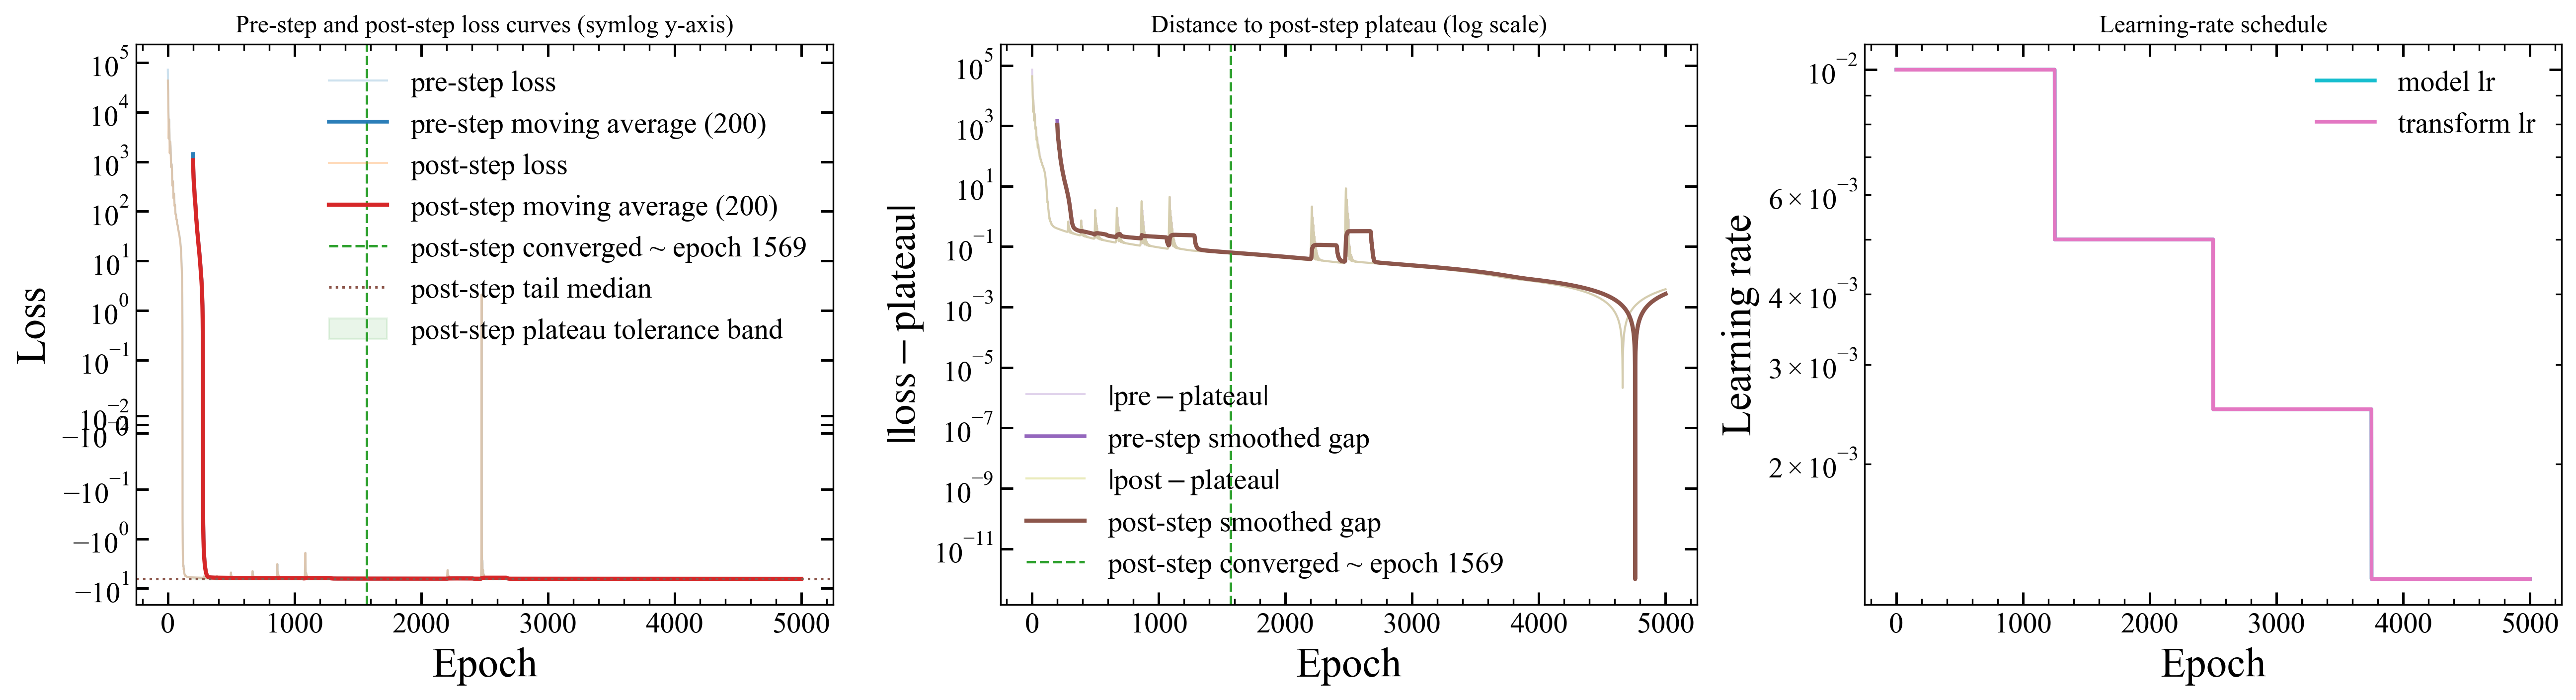

### 单次 NSA 训练的数据坍缩预览

Figures saved to:
  figures\fss_collapse_plot_nsa_single_preview.pdf
  figures\fss_collapse_plot_nsa_single_preview.png


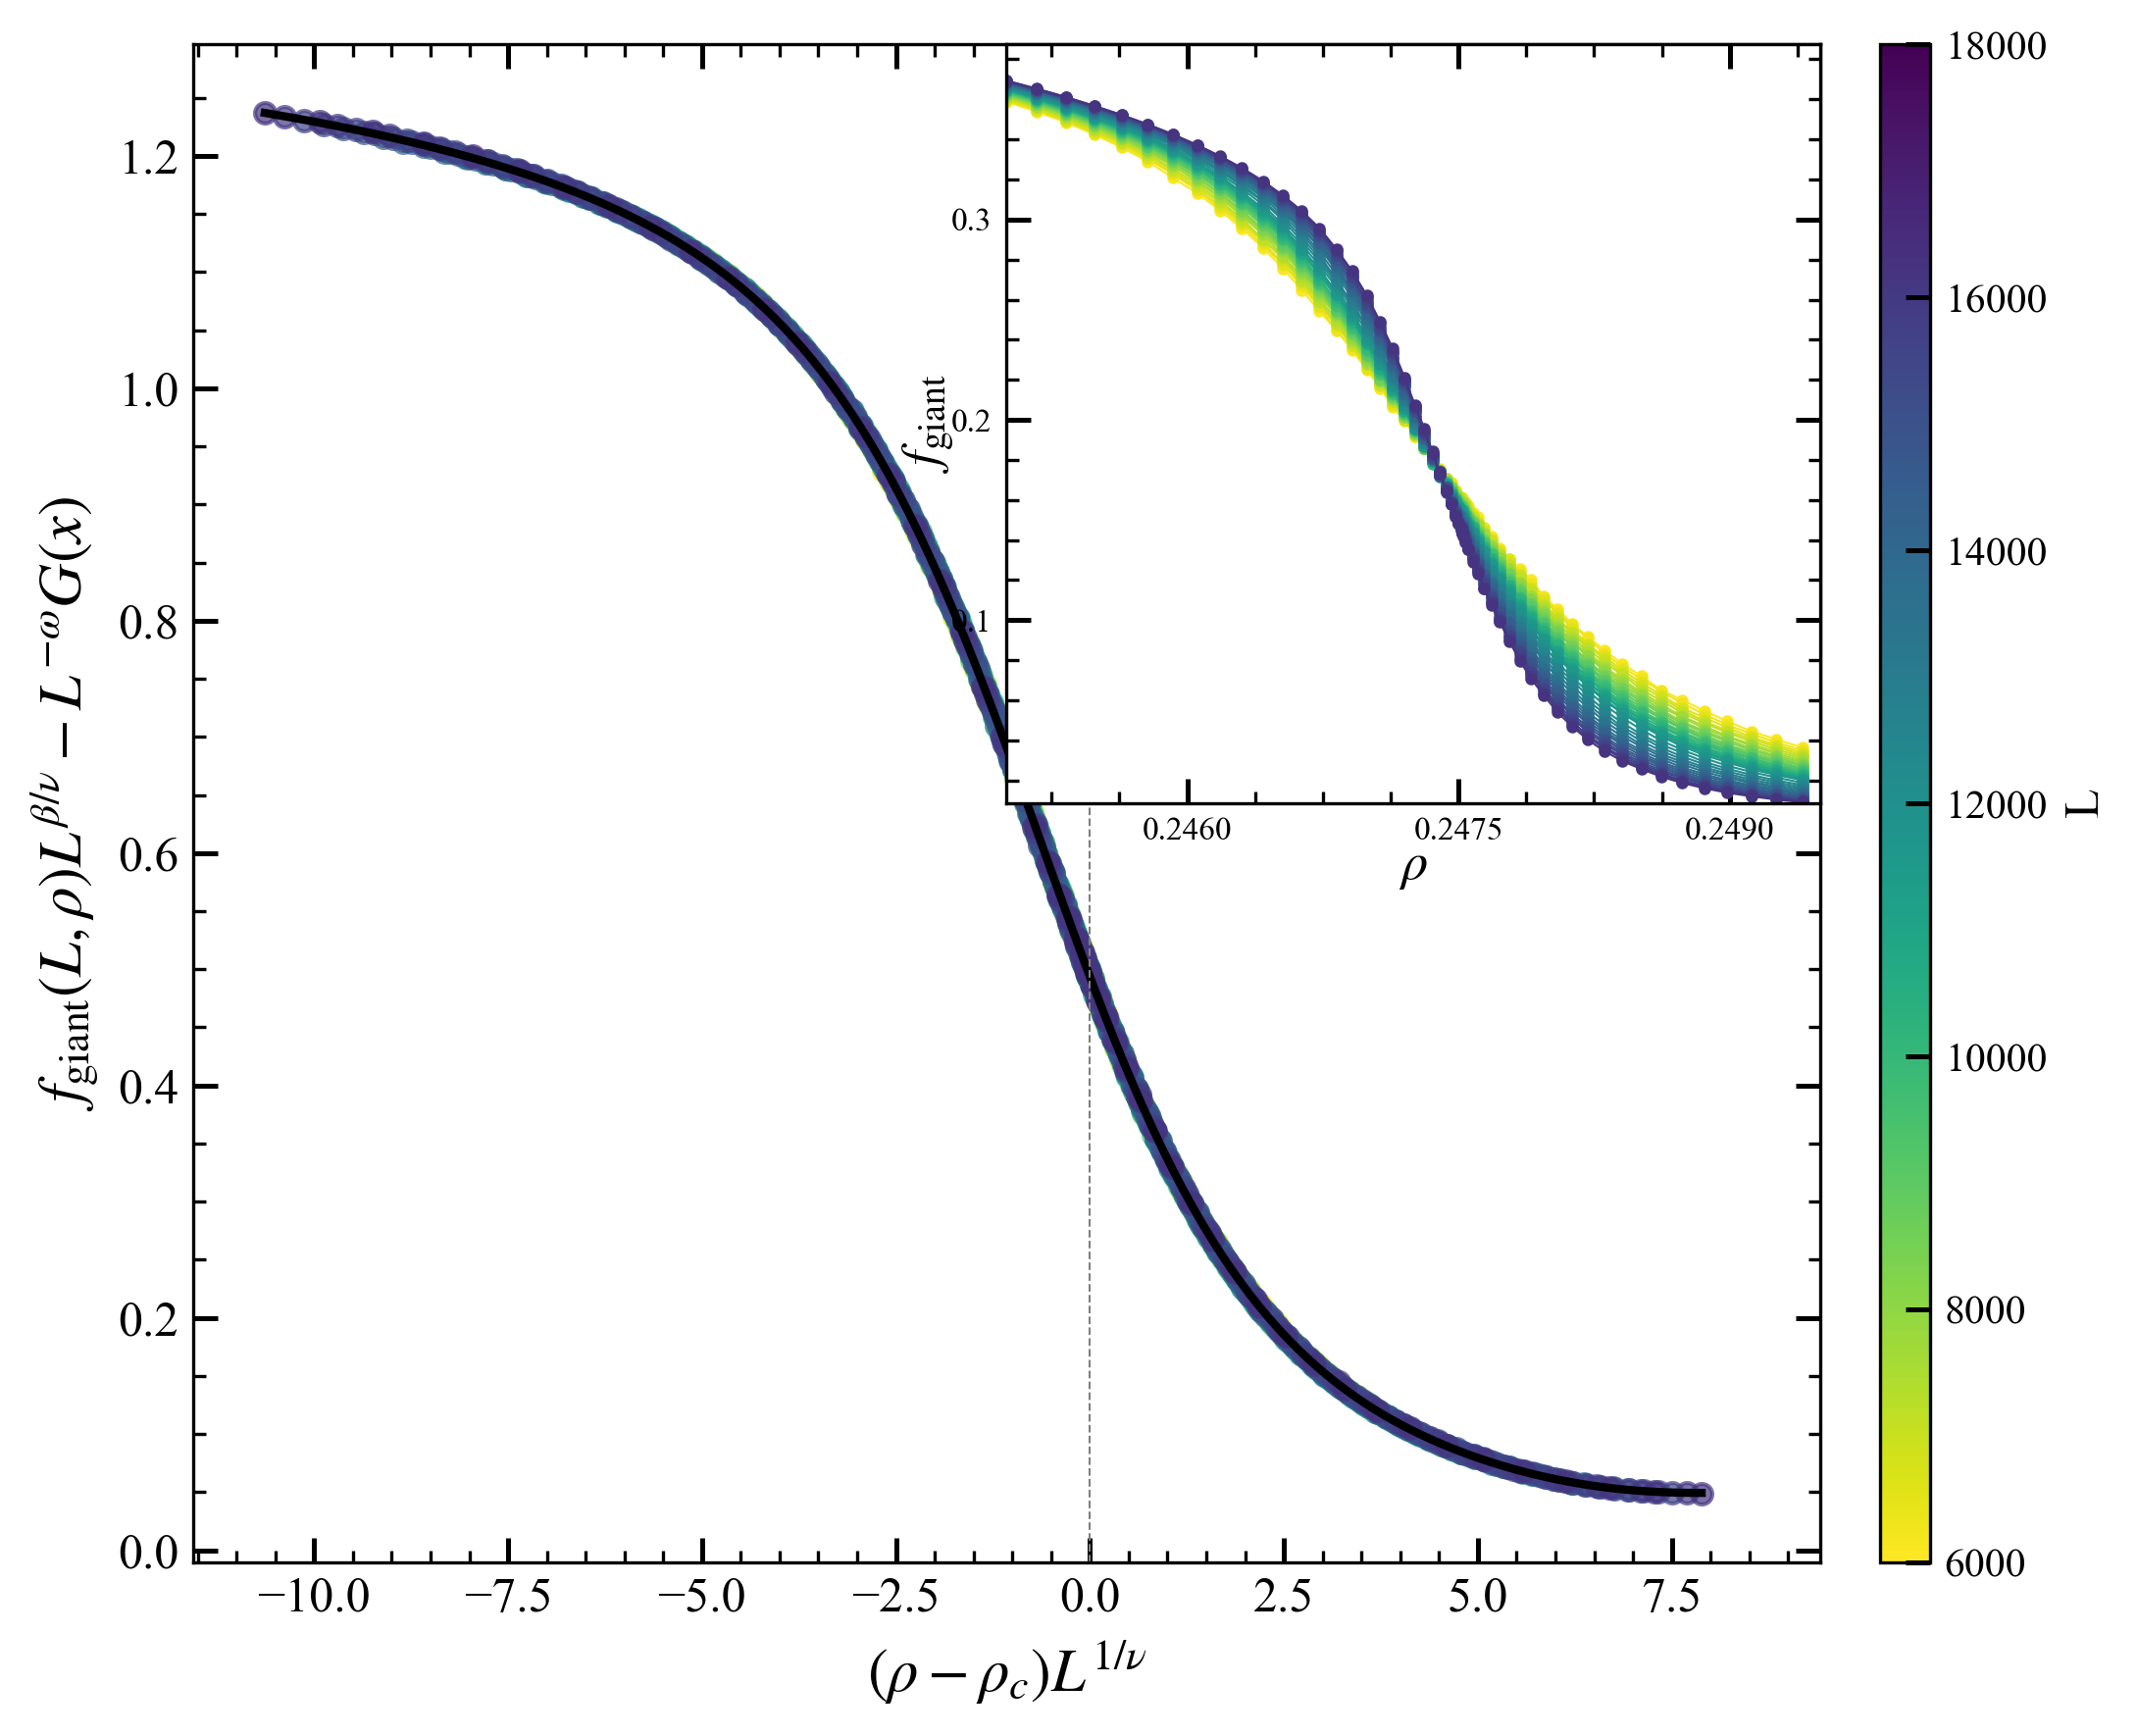

In [15]:
# ===================== 单次 NSA 训练：绘制 LOSS 收敛曲线 =====================
loss_preview_fit_frame = df[
    df['L'].isin(L_to_process) & df['rho'].between(RHO_FIT_WINDOW[0], RHO_FIT_WINDOW[1])
] .copy().sort_values(['L', 'rho']).reset_index(drop=True)

if loss_preview_fit_frame.empty:
    raise ValueError('No data points remain for the single-start NSA loss preview under the current RHO_FIT_WINDOW and L filters.')

loss_preview_result, loss_preview_cache_info, loss_preview_trial_results = load_or_run_loss_preview(loss_preview_fit_frame)

pre_step_loss_history = np.asarray(
    loss_preview_result.get('pre_step_loss_history', loss_preview_result['loss_history']),
    dtype=float,
)
post_step_loss_history = np.asarray(
    loss_preview_result.get('post_step_loss_history', loss_preview_result['loss_history']),
    dtype=float,
)
model_lr_history = np.asarray(
    loss_preview_result.get('model_lr_history', np.full(post_step_loss_history.shape, MODEL_LR, dtype=float)),
    dtype=float,
)
transform_lr_history = np.asarray(
    loss_preview_result.get('transform_lr_history', np.full(post_step_loss_history.shape, TRANSFORM_LR, dtype=float)),
    dtype=float,
)

pre_step_stats = estimate_loss_convergence(
    pre_step_loss_history,
    smooth_window=LOSS_PREVIEW_SMOOTH_WINDOW,
    relative_tol=LOSS_PREVIEW_RELATIVE_TOL,
    tail_fraction=LOSS_PREVIEW_TAIL_FRACTION,
)
post_step_stats = estimate_loss_convergence(
    post_step_loss_history,
    smooth_window=LOSS_PREVIEW_SMOOTH_WINDOW,
    relative_tol=LOSS_PREVIEW_RELATIVE_TOL,
    tail_fraction=LOSS_PREVIEW_TAIL_FRACTION,
)

pre_smoothed_loss = pre_step_stats['smoothed']
pre_smoothed_epochs = pre_step_stats['smoothed_epochs']
post_smoothed_loss = post_step_stats['smoothed']
post_smoothed_epochs = post_step_stats['smoothed_epochs']
plateau_loss = post_step_stats['tail_reference']
plateau_tolerance = post_step_stats['tolerance']
convergence_epoch = post_step_stats['convergence_epoch']

epochs = np.arange(1, len(post_step_loss_history) + 1)
pre_loss_gap = np.abs(pre_step_loss_history - plateau_loss) + 1e-12
post_loss_gap = np.abs(post_step_loss_history - plateau_loss) + 1e-12
pre_smoothed_gap = np.abs(pre_smoothed_loss - plateau_loss) + 1e-12
post_smoothed_gap = np.abs(post_smoothed_loss - plateau_loss) + 1e-12

loss_axis_linthresh = max(1e-6, float(plateau_tolerance))
loss_axis_positive = (
    np.all(pre_step_loss_history > 0)
    and np.all(post_step_loss_history > 0)
    and np.all(pre_smoothed_loss > 0)
    and np.all(post_smoothed_loss > 0)
    and (plateau_loss - plateau_tolerance > 0)
)
if loss_axis_positive:
    loss_axis_scale = 'log'
    loss_axis_title = 'Pre-step and post-step loss curves (log y-axis)'
else:
    loss_axis_scale = 'symlog'
    loss_axis_title = 'Pre-step and post-step loss curves (symlog y-axis)'

resolved_scheduler_step_size = loss_preview_result.get('lr_scheduler_step_size')
preview_summary = {
    'seed': LOSS_PREVIEW_SEED,
    'epochs': LOSS_PREVIEW_EPOCHS,
    'fit_points': int(len(loss_preview_fit_frame)),
    'fit_sizes': [int(L) for L in sorted(loss_preview_fit_frame['L'].unique())],
    'loss_mode': LOSS_MODE,
    'loss_axis_scale': loss_axis_scale if loss_axis_scale == 'log' else f'symlog (linthresh={loss_axis_linthresh:.3g})',
    'loss_recording': 'pre-step and post-step (convergence uses post-step)',
    'smooth_window': int(min(LOSS_PREVIEW_SMOOTH_WINDOW, len(post_step_loss_history))),
    'estimated_convergence_epoch': int(convergence_epoch),
    'plateau_loss_median': float(plateau_loss),
    'plateau_tolerance': float(plateau_tolerance),
    'lr_scheduler': loss_preview_result.get('lr_scheduler_name', 'constant'),
    'lr_decay_enabled': bool(loss_preview_result.get('lr_scheduler_active', False)),
    'lr_decay_step_size': None if resolved_scheduler_step_size is None else int(resolved_scheduler_step_size),
    'lr_decay_gamma': loss_preview_result.get('lr_scheduler_gamma'),
    'model_lr_init': float(model_lr_history[0]),
    'model_lr_final': float(model_lr_history[-1]),
    'transform_lr_init': float(transform_lr_history[0]),
    'transform_lr_final': float(transform_lr_history[-1]),
    'rho_c': float(loss_preview_result['rho_c']),
    'inv_nu': float(loss_preview_result['inv_nu']),
    'nu': float(loss_preview_result['nu']),
    'beta_over_nu': float(loss_preview_result['ratio']),
    'beta': float(loss_preview_result['beta']),
    'rmse': float(loss_preview_result['rmse']),
    'r2': float(loss_preview_result['r2']),
}

loss_preview_trial_table_columns = [
    'trial_id',
    'seed',
    'rho_c',
    'inv_nu',
    'nu',
    'beta_over_nu',
    'beta',
    'fit_rmse',
    'fit_r2',
    'ratio_positive',
    'selected_by_preview_rule',
]
if loss_preview_trial_results.empty:
    loss_preview_trial_table = pd.DataFrame(columns=loss_preview_trial_table_columns)
else:
    positive_preview_candidates = loss_preview_trial_results[loss_preview_trial_results['ratio_positive']]
    best_preview_candidates = (
        positive_preview_candidates
        if REQUIRE_POSITIVE_RATIO and (not positive_preview_candidates.empty)
        else loss_preview_trial_results
    )
    best_preview_trial_id = int(best_preview_candidates.sort_values(['rmse', 'rho_c']).iloc[0]['trial_id'])
    loss_preview_trial_table = (
        loss_preview_trial_results.loc[:, ['trial_id', 'seed', 'rho_c', 'inv_nu', 'nu', 'ratio', 'beta', 'rmse', 'r2', 'ratio_positive']]
        .rename(columns={
            'ratio': 'beta_over_nu',
            'rmse': 'fit_rmse',
            'r2': 'fit_r2',
        })
        .sort_values(['trial_id'])
        .reset_index(drop=True)
    )
    loss_preview_trial_table['selected_by_preview_rule'] = loss_preview_trial_table['trial_id'].eq(best_preview_trial_id)

display(Markdown('### 单次 NSA 训练的 loss 预览'))
display(loss_preview_cache_info)
display(preview_summary)
display(Markdown(f'### 单次预览对应的多起点拟合表（starts={FULL_FIT_STARTS}, epochs={LOSS_PREVIEW_EPOCHS}）'))
display(loss_preview_trial_table)

fig_loss, (ax_loss, ax_gap, ax_lr) = plt.subplots(1, 3, figsize=(17.4, 4.8))

ax_loss.plot(epochs, pre_step_loss_history, color='tab:blue', linewidth=1.0, alpha=0.22, label='pre-step loss')
ax_loss.plot(pre_smoothed_epochs, pre_smoothed_loss, color='tab:blue', linewidth=1.8, alpha=0.95, label=f'pre-step moving average ({preview_summary["smooth_window"]})')
ax_loss.plot(epochs, post_step_loss_history, color='tab:orange', linewidth=1.0, alpha=0.28, label='post-step loss')
ax_loss.plot(post_smoothed_epochs, post_smoothed_loss, color='tab:red', linewidth=2.0, label=f'post-step moving average ({preview_summary["smooth_window"]})')
ax_loss.axvline(convergence_epoch, color='tab:green', linestyle='--', linewidth=1.2, label=f'post-step converged ~ epoch {convergence_epoch}')
ax_loss.axhline(plateau_loss, color='tab:brown', linestyle=':', linewidth=1.2, label='post-step tail median')
ax_loss.fill_between(
    post_smoothed_epochs,
    plateau_loss - plateau_tolerance,
    plateau_loss + plateau_tolerance,
    color='tab:green',
    alpha=0.10,
    label='post-step plateau tolerance band',
)
if loss_axis_scale == 'log':
    ax_loss.set_yscale('log')
else:
    ax_loss.set_yscale('symlog', linthresh=loss_axis_linthresh)
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Loss')
ax_loss.set_title(loss_axis_title)
ax_loss.minorticks_on()
ax_loss.legend(frameon=SHOW_LEGEND_FRAME, fancybox=False, shadow=False)

ax_gap.semilogy(epochs, pre_loss_gap, color='tab:purple', linewidth=1.0, alpha=0.28, label=r'$|\mathrm{pre}-\mathrm{plateau}|$')
ax_gap.semilogy(pre_smoothed_epochs, pre_smoothed_gap, color='tab:purple', linewidth=1.8, label='pre-step smoothed gap')
ax_gap.semilogy(epochs, post_loss_gap, color='tab:olive', linewidth=1.0, alpha=0.30, label=r'$|\mathrm{post}-\mathrm{plateau}|$')
ax_gap.semilogy(post_smoothed_epochs, post_smoothed_gap, color='tab:brown', linewidth=2.0, label='post-step smoothed gap')
ax_gap.axvline(convergence_epoch, color='tab:green', linestyle='--', linewidth=1.2, label=f'post-step converged ~ epoch {convergence_epoch}')
ax_gap.set_xlabel('Epoch')
ax_gap.set_ylabel(r'$|\mathrm{loss}-\mathrm{plateau}|$')
ax_gap.set_title('Distance to post-step plateau (log scale)')
ax_gap.minorticks_on()
ax_gap.legend(frameon=SHOW_LEGEND_FRAME, fancybox=False, shadow=False)

ax_lr.plot(epochs, model_lr_history, color='tab:cyan', linewidth=1.8, label='model lr')
ax_lr.plot(epochs, transform_lr_history, color='tab:pink', linewidth=1.8, label='transform lr')
if np.all(model_lr_history > 0) and np.all(transform_lr_history > 0):
    ax_lr.set_yscale('log')
ax_lr.set_xlabel('Epoch')
ax_lr.set_ylabel('Learning rate')
ax_lr.set_title('Learning-rate schedule')
ax_lr.minorticks_on()
ax_lr.legend(frameon=SHOW_LEGEND_FRAME, fancybox=False, shadow=False)

plt.tight_layout()
plt.show()

loss_preview_plot_frame = df[
    df['L'].isin(unique_Ls_filtered) & df['rho'].between(RHO_COLLAPSE_PLOT_WINDOW[0], RHO_COLLAPSE_PLOT_WINDOW[1])
].copy().sort_values(['L', 'rho']).reset_index(drop=True)

display(Markdown('### 单次 NSA 训练的数据坍缩预览'))
loss_preview_collapsed_plot_df = plot_nsa_collapse_result(
    loss_preview_result,
    loss_preview_plot_frame,
    save_name='fss_collapse_plot_nsa_single_preview',
)




# 开跑：完整拟合、Bootstrap 与缓存


In [16]:
# ===================== Execute NSA fit (or load cache) and summarize results =====================
# Keep only the L values used for fitting and the points inside the fit window.
fit_frame = df[df['L'].isin(L_to_process) & df['rho'].between(RHO_FIT_WINDOW[0], RHO_FIT_WINDOW[1])].copy().sort_values(['L', 'rho']).reset_index(drop=True)
if fit_frame.empty:
    raise ValueError('No data points remain for the NSA fit under the current RHO_FIT_WINDOW and L filters.')

fit_setup = {
    'fit_sizes': L_to_process,
    'n_fit_sizes': len(L_to_process),
    'n_plot_sizes': len(unique_Ls_filtered),
    'fit_window_requested': RHO_FIT_WINDOW,
    'fit_window_actual': [float(fit_frame['rho'].min()), float(fit_frame['rho'].max())],
    'fit_rows': int(len(fit_frame)),
    'loss_mode': LOSS_MODE,
    'use_first_order_correction': USE_FIRST_ORDER_CORRECTION,
    'correction_formula': 'P(L, rho) L^{beta/nu} = F(x) + L^{-omega} G(x)' if USE_FIRST_ORDER_CORRECTION else None,
    'correction_hidden_sizes': None if CORRECTION_MLP_HIDDEN_SIZES is None else list(CORRECTION_MLP_HIDDEN_SIZES),
    'correction_omega_init': CORRECTION_OMEGA_INIT if USE_FIRST_ORDER_CORRECTION else None,
    'epochs_per_start': FULL_FIT_EPOCHS,
    'model_lr': MODEL_LR,
    'transform_lr': TRANSFORM_LR,
    'use_step_lr_decay': USE_STEP_LR_DECAY,
    'lr_decay_step_size': resolve_lr_decay_step_size(FULL_FIT_EPOCHS) if USE_STEP_LR_DECAY else None,
    'lr_decay_gamma': LR_DECAY_GAMMA if USE_STEP_LR_DECAY else None,
    'n_starts': FULL_FIT_STARTS,
    'ratio_positive_filter': REQUIRE_POSITIVE_RATIO,
    'run_bootstrap': RUN_BOOTSTRAP,
    'bootstrap_repeats': BOOTSTRAP_REPEATS,
    'bootstrap_fit_epochs': BOOTSTRAP_FIT_EPOCHS,
    'bootstrap_fit_starts': BOOTSTRAP_FIT_STARTS,
    'bootstrap_point_sample_size': BOOTSTRAP_POINT_SAMPLE_SIZE,
    'bootstrap_parallel_workers': BOOTSTRAP_PARALLEL_WORKERS,
    'bootstrap_torch_threads_per_worker': BOOTSTRAP_TORCH_THREADS_PER_WORKER,
    'torch_device': TORCH_DEVICE_INFO['torch_device'],
    'torch_device_name': TORCH_DEVICE_INFO['cuda_device_name'],
    'nsa_cache_file': os.path.abspath(NSA_CACHE_FILE),
    'force_recompute_nsa': FORCE_RECOMPUTE_NSA,
    'loss_preview_cache_file': os.path.abspath(LOSS_PREVIEW_CACHE_FILE),
    'force_recompute_loss_preview': FORCE_RECOMPUTE_LOSS_PREVIEW,
    'raw_bootstrap_lookup_cache_file': os.path.abspath(RAW_BOOTSTRAP_LOOKUP_CACHE_FILE),
    'force_rebuild_raw_bootstrap_lookup_cache': FORCE_REBUILD_RAW_BOOTSTRAP_LOOKUP_CACHE,
}

display(Markdown('### NSA Fit Setup'))
display(fit_setup)

if USE_FIRST_ORDER_CORRECTION:
    display(Markdown('### First-order correction ansatz'))
    display(Markdown(r'$P(L,\rho)L^{\beta/\nu} = F(x) + L^{-\omega}G(x)$'))

display(fit_frame.groupby('L')['rho'].nunique().rename('n_rho_points').to_frame())

cache_signature = build_nsa_cache_signature(build_nsa_cache_config(), fit_frame)
cache_source = 'recomputed'
cache_message = 'A fresh NSA fit will be computed.'
cached_created_at = None
cache_payload = None
full_fit_result = None
trial_results_table = pd.DataFrame()
bootstrap_results = pd.DataFrame()
bootstrap_raw_info = None
summary_row = None

if FORCE_RECOMPUTE_NSA:
    cache_message = 'FORCE_RECOMPUTE_NSA=True, so the existing NSA cache was ignored.'
elif not os.path.exists(NSA_CACHE_FILE):
    cache_message = 'No NSA cache file was found, so a fresh fit will be computed.'
else:
    try:
        candidate_payload = load_nsa_cache(NSA_CACHE_FILE)
        if candidate_payload.get('cache_version') != CACHE_VERSION:
            cache_message = f"Cache version mismatch: {candidate_payload.get('cache_version')} != {CACHE_VERSION}."
        elif candidate_payload.get('signature') != cache_signature:
            cache_message = 'The cached NSA result does not match the current fit configuration/data.'
        else:
            cache_payload = candidate_payload
            full_fit_result = restore_fit_result_from_cache(
                candidate_payload,
                fit_frame,
                dataset_builder=build_dataset_from_frame,
                model_builder=build_nsa_model,
                device=TORCH_DEVICE,
            )
            trial_results_table = records_to_dataframe(candidate_payload.get('trial_results_records'))
            bootstrap_results = records_to_dataframe(candidate_payload.get('bootstrap_results_records'))
            bootstrap_raw_info = candidate_payload.get('bootstrap_raw_info')
            summary_row = dict(candidate_payload.get('summary_row') or {})
            cache_source = 'cache'
            cached_created_at = candidate_payload.get('created_at_utc')
            cache_message = 'Loaded a compatible cached NSA result.'
    except Exception as exc:
        cache_message = f'Failed to load the NSA cache ({type(exc).__name__}: {exc}).'

if cache_source != 'cache':
    full_fit_result, trial_results_table = fit_best_of_n(
        fit_frame,
        n_starts=FULL_FIT_STARTS,
        num_epochs=FULL_FIT_EPOCHS,
        base_seed=SEED,
        keep_model=True,
        show_progress=SHOW_TQDM,
        progress_prefix='NSA full fit',
        progress_leave=TQDM_LEAVE,
    )

    if RUN_BOOTSTRAP and BOOTSTRAP_REPEATS > 0:
        bootstrap_results, bootstrap_raw_info = bootstrap_analysis_from_raw(
            fit_frame,
            raw_file_path=BOOTSTRAP_RAW_FILE_PATH,
            repeats=BOOTSTRAP_REPEATS,
            base_seed=SEED + 100000,
            n_starts=BOOTSTRAP_FIT_STARTS,
            num_epochs=BOOTSTRAP_FIT_EPOCHS,
            sample_size=BOOTSTRAP_POINT_SAMPLE_SIZE,
            show_progress=SHOW_TQDM,
            progress_leave=TQDM_LEAVE,
            parallel_workers=BOOTSTRAP_PARALLEL_WORKERS,
            torch_threads_per_worker=BOOTSTRAP_TORCH_THREADS_PER_WORKER,
        )

    summary_row = summarize_with_bootstrap(
        full_fit_result,
        bootstrap_frame=bootstrap_results,
        fit_sizes=L_to_process,
        n_points=len(fit_frame),
    )
    cache_payload = create_nsa_cache_payload(
        signature=cache_signature,
        fit_result=full_fit_result,
        trial_results_table=trial_results_table,
        bootstrap_results=bootstrap_results,
        bootstrap_raw_info=bootstrap_raw_info,
        summary_row=summary_row,
        fit_setup=fit_setup,
    )
    save_nsa_cache(NSA_CACHE_FILE, cache_payload)
    cached_created_at = cache_payload.get('created_at_utc')
    cache_message = f"{cache_message} Saved the refreshed cache to {os.path.abspath(NSA_CACHE_FILE)}."

if not summary_row:
    summary_row = summarize_with_bootstrap(
        full_fit_result,
        bootstrap_frame=bootstrap_results,
        fit_sizes=L_to_process,
        n_points=len(fit_frame),
    )

summary_table_row = {
    r'$\rho_c$': summary_row['rho_c_text'],
    r'$1/\nu$': summary_row['inv_nu_text'],
    r'$\nu$': summary_row['nu_text'],
    r'$\beta/\nu$': summary_row['ratio_text'],
    r'$\beta$': summary_row['beta_text'],
}
if USE_FIRST_ORDER_CORRECTION and ('omega_text' in summary_row):
    summary_table_row[r'$\omega$'] = summary_row['omega_text']
summary_table_row.update({
    'RMSE': summary_row['rmse_text'],
    r'$R^2$': summary_row['r2_text'],
    'fit_sizes': summary_row['fit_sizes'],
    'n_points': summary_row['n_points'],
    'bootstrap_repeats': summary_row['bootstrap_repeats'],
})
summary_table = pd.DataFrame([summary_table_row])

academic_lines = [
    rf"- $\rho_c = {summary_row['rho_c_text']}$",
    rf"- $1/\nu = {summary_row['inv_nu_text']}$",
    rf"- $\nu = {summary_row['nu_text']}$",
    rf"- $\beta/\nu = {summary_row['ratio_text']}$",
    rf"- $\beta = {summary_row['beta_text']}$",
]
if USE_FIRST_ORDER_CORRECTION and ('omega_text' in summary_row):
    academic_lines.append(rf"- $\omega = {summary_row['omega_text']}$")
academic_lines.extend([
    rf"- $\mathrm{{RMSE}} = {summary_row['rmse_text']}$",
    rf"- $R^2 = {summary_row['r2_text']}$",
])

display(Markdown('### NSA Cache'))
display({
    'cache_source': cache_source,
    'cache_file': os.path.abspath(NSA_CACHE_FILE),
    'cache_signature': cache_signature,
    'cache_created_at_utc': cached_created_at,
    'message': cache_message,
})

display(Markdown('### Multi-start Results'))
display(trial_results_table.sort_values(['rmse', 'rho_c']).reset_index(drop=True))

if bootstrap_raw_info is not None:
    display(Markdown('### Raw Bootstrap Setup'))
    bootstrap_setup = dict(bootstrap_raw_info)
    bootstrap_setup.update({
        'torch_device': TORCH_DEVICE_INFO['torch_device'],
        'torch_device_name': TORCH_DEVICE_INFO['cuda_device_name'],
        'bootstrap_repeats': BOOTSTRAP_REPEATS,
        'bootstrap_fit_epochs': BOOTSTRAP_FIT_EPOCHS,
        'bootstrap_fit_starts': BOOTSTRAP_FIT_STARTS,
        'point_resample_size': bootstrap_raw_info['samples_per_point_max'] if BOOTSTRAP_POINT_SAMPLE_SIZE is None else BOOTSTRAP_POINT_SAMPLE_SIZE,
        'bootstrap_parallel_workers_requested': BOOTSTRAP_PARALLEL_WORKERS,
        'bootstrap_torch_threads_per_worker_requested': BOOTSTRAP_TORCH_THREADS_PER_WORKER,
    })
    display(bootstrap_setup)
    bootstrap_stat_columns = ['rho_c', 'inv_nu', 'nu', 'ratio', 'beta']
    if USE_FIRST_ORDER_CORRECTION and ('omega' in bootstrap_results.columns):
        bootstrap_stat_columns.append('omega')
    bootstrap_stat_columns.extend(['rmse', 'r2'])
    display(Markdown('### Bootstrap Replicate Statistics'))
    display(bootstrap_results[bootstrap_stat_columns].agg(['mean', 'std']))

display(Markdown('### Academic-style Estimates'))
display(Markdown('\n'.join(academic_lines)))
display(Markdown('### Summary Table'))
display(summary_table)


### NSA Fit Setup

{'fit_sizes': [6000,
  6200,
  6400,
  6600,
  6800,
  7000,
  7200,
  7400,
  7600,
  7800,
  8000,
  8200,
  8400,
  8600,
  8800,
  9000,
  9200,
  9400,
  9600,
  9800,
  10000,
  10500,
  11000,
  11500,
  12000,
  12500,
  13000,
  13500,
  14000,
  14500,
  15000,
  15500,
  16000,
  16500,
  17000,
  17500,
  18000],
 'n_fit_sizes': 37,
 'n_plot_sizes': 37,
 'fit_window_requested': [0.245, 0.2495],
 'fit_window_actual': [0.245, 0.24940294],
 'fit_rows': 2072,
 'loss_mode': 'gaussian_nll',
 'use_first_order_correction': True,
 'correction_formula': 'P(L, rho) L^{beta/nu} = F(x) + L^{-omega} G(x)',
 'correction_hidden_sizes': [32, 32],
 'correction_omega_init': 1.0,
 'epochs_per_start': 5000,
 'model_lr': 0.01,
 'transform_lr': 0.01,
 'use_step_lr_decay': True,
 'lr_decay_step_size': 1250,
 'lr_decay_gamma': 0.5,
 'n_starts': 3,
 'ratio_positive_filter': True,
 'run_bootstrap': True,
 'bootstrap_repeats': 10,
 'bootstrap_fit_epochs': 5000,
 'bootstrap_fit_starts': 1,
 'bootstrap_

### First-order correction ansatz

$P(L,\rho)L^{\beta/\nu} = F(x) + L^{-\omega}G(x)$

,n_rho_points
L,
6000,56
6200,56
6400,56
6600,56
6800,56
7000,56
7200,56
7400,56
7600,56


NSA full fit | start 1/3:   0%|          | 0/5000 [00:00<?, ?it/s]

NSA full fit | start 2/3:   0%|          | 0/5000 [00:00<?, ?it/s]

NSA full fit | start 3/3:   0%|          | 0/5000 [00:00<?, ?it/s]

KeyboardInterrupt: 

# 最优 NSA 数据坍缩图


### 最优 NSA 数据坍缩图

Figures saved to:
  figures\fss_collapse_plot_nsa.pdf
  figures\fss_collapse_plot_nsa.png


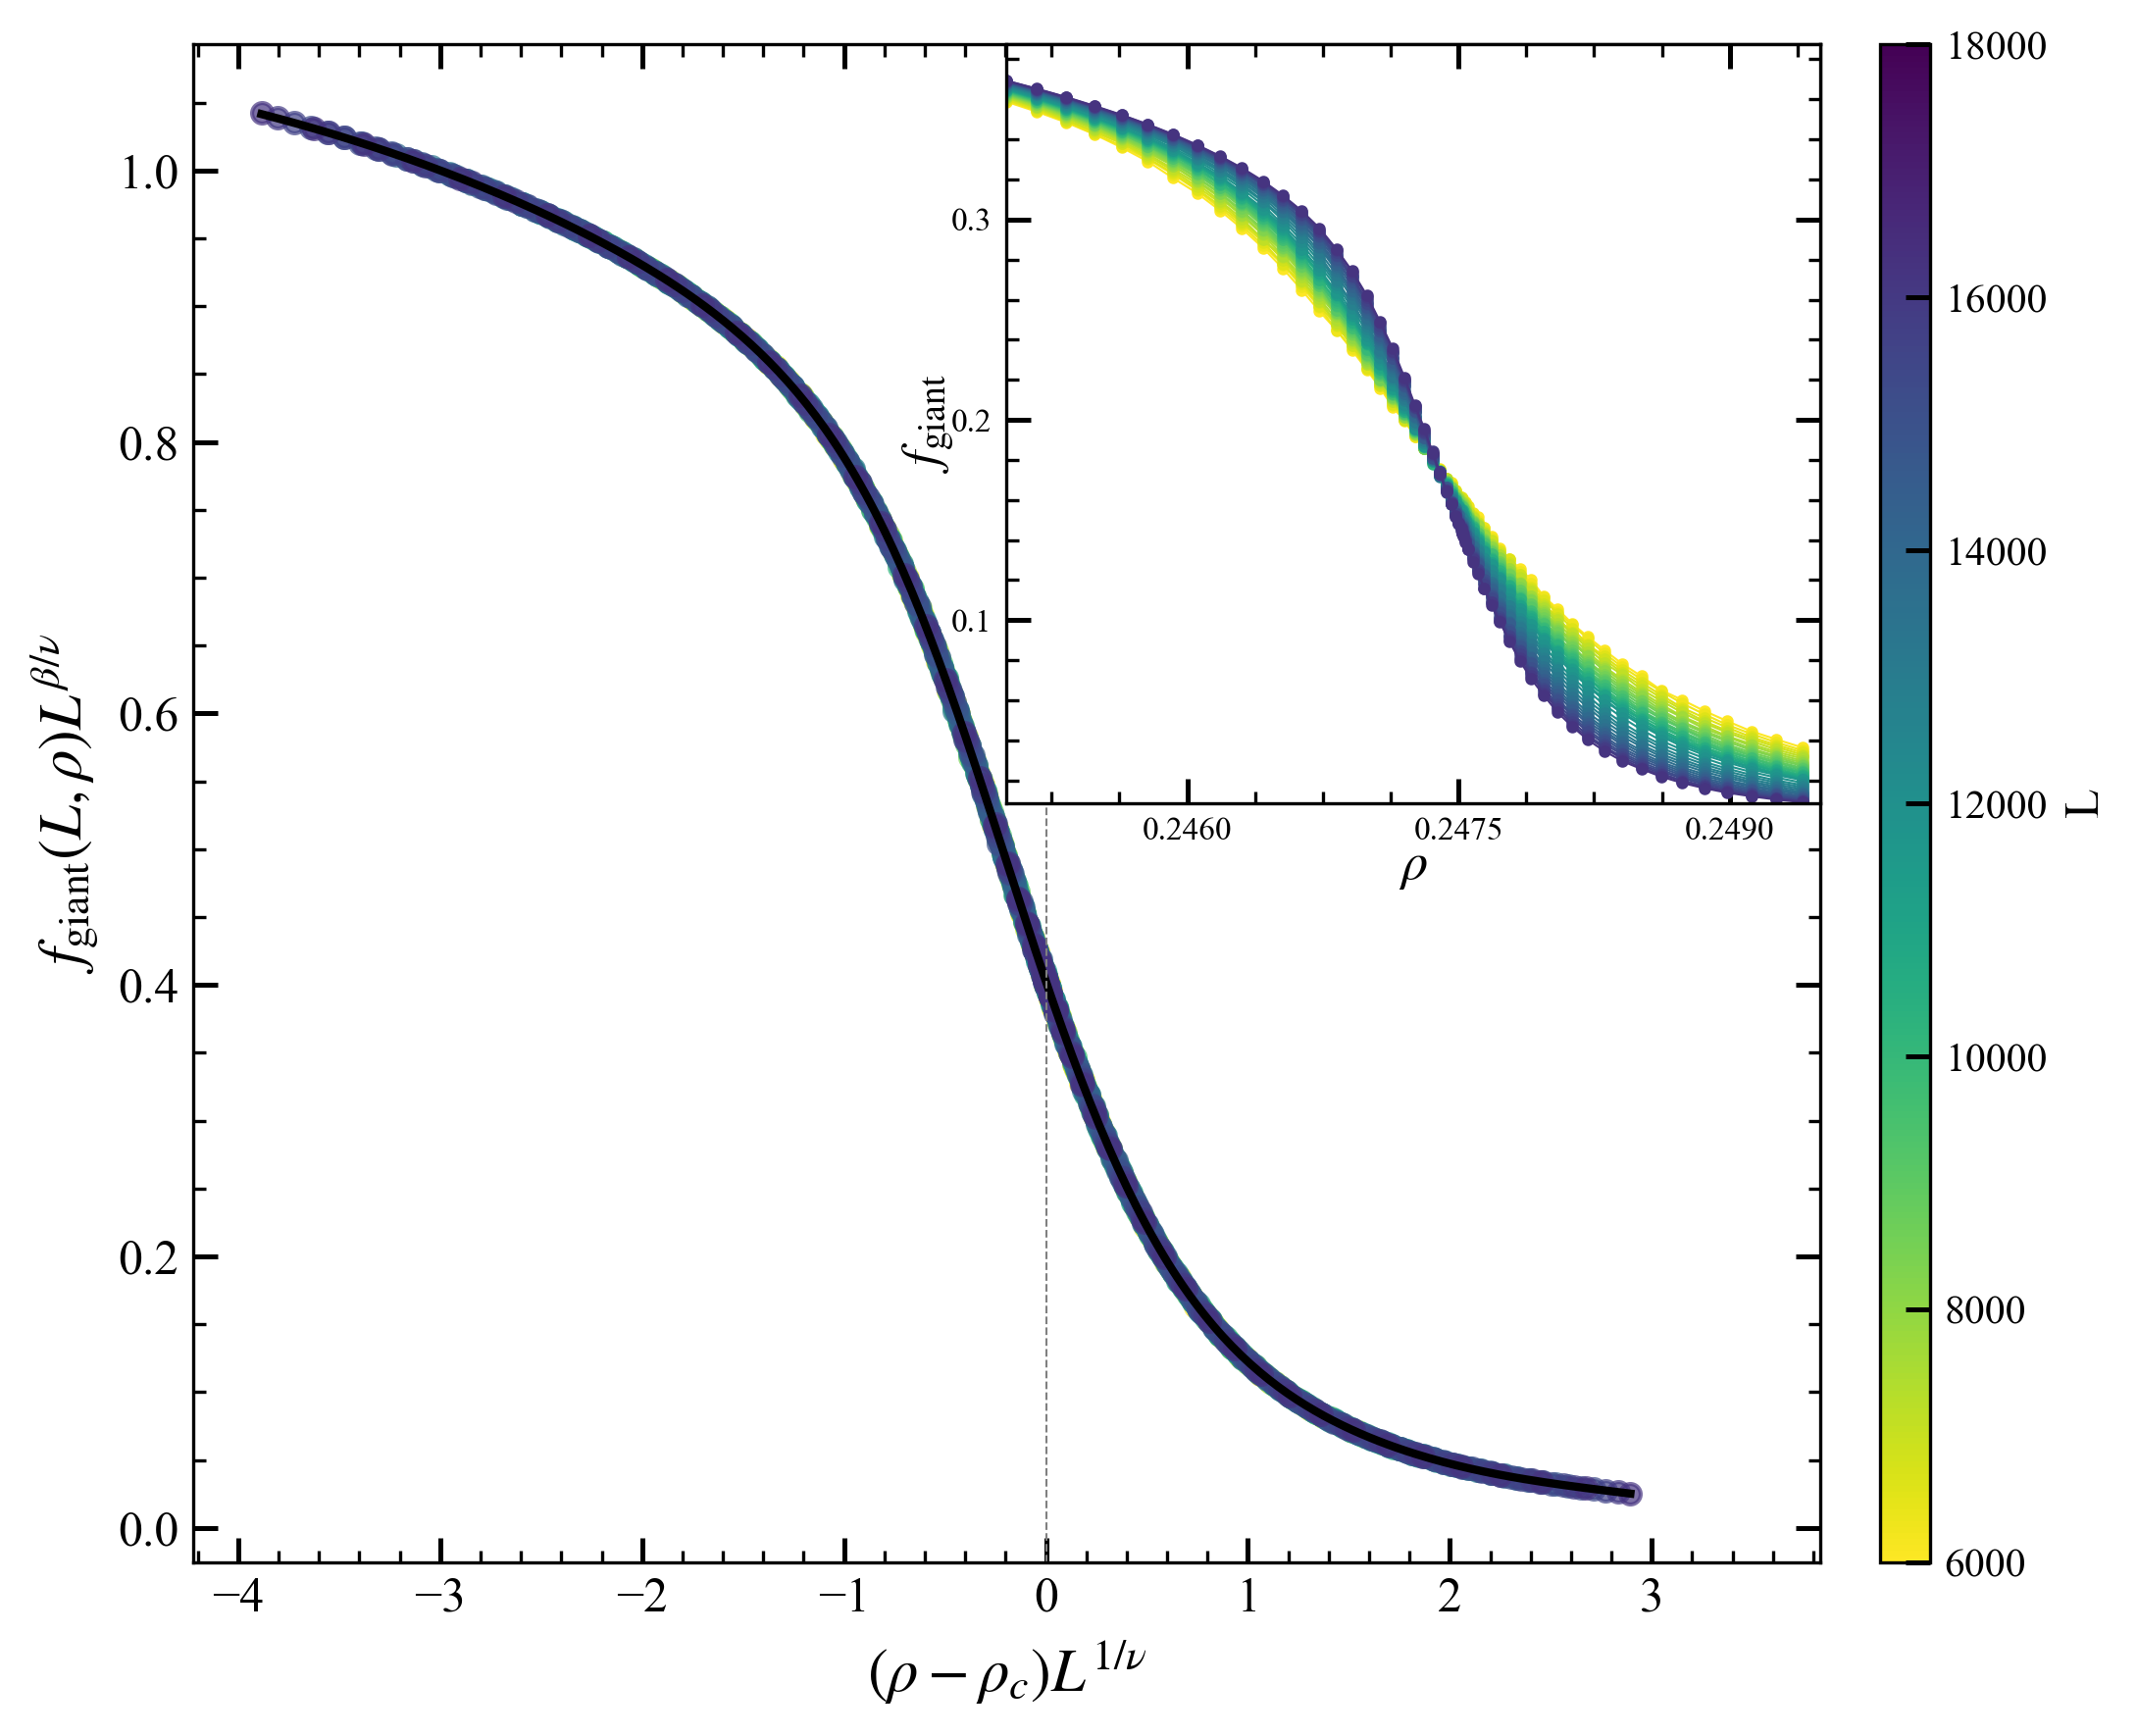

In [ ]:
# ===================== 根据最优 NSA 结果绘制数据坍缩图 =====================
# 这里允许绘图窗口与拟合窗口不同：
# 拟合只需要临界区附近的点，而展示时可以适当放宽，观察坍缩在更大范围内是否依然稳定。
plot_collapse_data_df = df[df['L'].isin(unique_Ls_filtered) & df['rho'].between(RHO_COLLAPSE_PLOT_WINDOW[0], RHO_COLLAPSE_PLOT_WINDOW[1])].copy().sort_values(['L', 'rho']).reset_index(drop=True)

display(Markdown('### 最优 NSA 数据坍缩图'))
collapsed_plot_df = plot_nsa_collapse_result(
    full_fit_result,
    plot_collapse_data_df,
    save_name='fss_collapse_plot_nsa',
)


{'validation_use_first_order_correction': True,
 'validation_omega': 0.9881359338760376,
 'validation_rmse': 0.22346331179141998}